In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install google-cloud-bigquery pandas
from google.cloud import bigquery
from google.colab import auth
import pandas as pd

In [3]:
auth.authenticate_user()

In [4]:
project_id = 'delhi-metro-project-503214'
client = bigquery.Client(project=project_id)

In [5]:
query = """
       SELECT *
       FROM `delhi-metro-project-503214.Delhi_Metro.delhi_metro`
       LIMIT 100
"""
df = client.query(query).to_dataframe()

In [6]:
print(df.head())

   TripID        Date       From_Station            To_Station  Distance_km  \
0  110323  2022-01-01  Noida City Centre        Rajouri Garden         4.73   
1    8507  2022-01-01        Laxmi Nagar  Netaji Subhash Place         1.06   
2   11884  2022-01-01           Inderlok        Kalkaji Mandir         4.72   
3   48906  2022-01-01        Rajiv Chowk   Central Secretariat         2.67   
4   75424  2022-01-01  Noida City Centre         Chandni Chowk         6.48   

     Fare  Cost_per_passenger  Passengers Ticket_Type Remarks  
0   72.06               36.10        20.0      Single    None  
1  124.48               55.16        15.0      Single    None  
2   80.93               93.25         8.0  Smart Card    None  
3  170.26              105.27        17.0      Single    None  
4   42.65               38.85        15.0  Smart Card    None  


In [7]:
#1. basic stats and structure
print("---dataframe info---")
df.info()
#2. missing values
print("---missing values---")
print(df.isnull().sum())
#3. duplicate values
print("---duplicate values---")
print(df.duplicated().sum())
#4. Range and unique values
print("---Range and unique values---")
print(df.describe())
print(df.nunique())
print(df['Ticket_Type'].value_counts())

---dataframe info---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   TripID              100 non-null    Int64  
 1   Date                100 non-null    dbdate 
 2   From_Station        100 non-null    object 
 3   To_Station          100 non-null    object 
 4   Distance_km         100 non-null    float64
 5   Fare                100 non-null    float64
 6   Cost_per_passenger  100 non-null    float64
 7   Passengers          99 non-null     float64
 8   Ticket_Type         97 non-null     object 
 9   Remarks             0 non-null      object 
dtypes: Int64(1), dbdate(1), float64(4), object(4)
memory usage: 8.0+ KB
---missing values---
TripID                  0
Date                    0
From_Station            0
To_Station              0
Distance_km             0
Fare                    0
Cost_per_passenger      0
Passengers 

In [13]:
from google.cloud import bigquery

client = bigquery.Client(project='delhi-metro-project-503214')

# Datasets list karo
datasets = list(client.list_datasets())

if datasets:
    print("📌 Available Datasets in your Project:")
    for dataset in datasets:
        print(f"\n -> Dataset ID: {dataset.dataset_id}")

        # Is dataset ke andar ki tables list karo
        tables = list(client.list_tables(dataset.dataset_id))
        if tables:
            for table in tables:
                print(f"    └── Table ID: {table.table_id}")
        else:
            print("    └── (No tables found in this dataset)")
else:
    print("❌ No datasets found in this project. BigQuery UI par dataset create karna hoga.")

📌 Available Datasets in your Project:

 -> Dataset ID: Delhi_Metro
    └── Table ID: delhi_metro


In [15]:
import pandas as pd
import numpy as np
import sqlite3
from google.cloud import bigquery

# Client initialization
project_id = 'delhi-metro-project-503214'
client = bigquery.Client(project=project_id)

print("🚀 [1/5] Extracting full dataset from BigQuery...")

# Full dataset extraction query (No LIMIT)
full_query = """
SELECT *
FROM `delhi-metro-project-503214.Delhi_Metro.delhi_metro`
"""

df_raw = client.query(full_query).to_dataframe()
print(f"✔ Extracted Raw Dataset Shape: {df_raw.shape}")

# -------------------------------------------------------------
# STEP 2: TRANSFORM & CLEAN (Data Hygiene)
# -------------------------------------------------------------
print("🧹 [2/5] Cleaning & Transforming Data...")

df_clean = df_raw.copy()

# A. String Standardization
df_clean['From_Station'] = df_clean['From_Station'].astype(str).str.strip().str.title()
df_clean['To_Station'] = df_clean['To_Station'].astype(str).str.strip().str.title()

# B. Handle Categorical Missing Values
df_clean['Ticket_Type'] = df_clean['Ticket_Type'].fillna('Unknown').astype(str).str.strip().str.title()
df_clean['Remarks'] = df_clean['Remarks'].fillna('Regular').astype(str).str.strip().str.lower()

# C. Cast & Impute Numeric Nulls
median_passengers = df_clean['Passengers'].median()
df_clean['Passengers'] = df_clean['Passengers'].fillna(median_passengers).astype(int)

# D. Date Formatting
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

# E. Deduplicate Rows
df_clean = df_clean.drop_duplicates()

# -------------------------------------------------------------
# STEP 3: FEATURE ENGINEERING (Analytical Columns)
# -------------------------------------------------------------
print("⚙️ [3/5] Creating Calculated Features...")

# Total Revenue Generated per trip
df_clean['Total_Revenue'] = df_clean['Passengers'] * df_clean['Fare']

# Route Identifier (Origin -> Destination)
df_clean['Route'] = df_clean['From_Station'] + " -> " + df_clean['To_Station']

# Time Features
df_clean['Day_Name'] = df_clean['Date'].dt.day_name()
df_clean['Year_Month'] = df_clean['Date'].dt.to_period('M').astype(str)

# -------------------------------------------------------------
# STEP 4: LOAD TO LOCAL SQLITE (For Fast Queries)
# -------------------------------------------------------------
print("🗄️ [4/5] Loading into Local SQLite Database...")

conn = sqlite3.connect('delhi_metro_clean.db')
df_clean.to_sql('fact_metro_trips', conn, if_exists='replace', index=False)

cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM fact_metro_trips")
loaded_count = cursor.fetchone()[0]
print(f"✅ Loaded {loaded_count:,} Rows into SQLite 'fact_metro_trips'!")
conn.close()

# -------------------------------------------------------------
# STEP 5: LOAD BACK TO BIGQUERY (Clean Table)
# -------------------------------------------------------------
print("☁️ [5/5] Saving Clean Table in BigQuery as 'clean_fact_trips'...")

job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",
)

target_table_id = f"{project_id}.Delhi_Metro.clean_fact_trips"
job = client.load_table_from_dataframe(df_clean, target_table_id, job_config=job_config)
job.result()

print("🎉 PHASE 7 COMPLETE! Data Cleaned, Transformed & Stored Successfully.")

🚀 [1/5] Extracting full dataset from BigQuery...
✔ Extracted Raw Dataset Shape: (150000, 10)
🧹 [2/5] Cleaning & Transforming Data...
⚙️ [3/5] Creating Calculated Features...
🗄️ [4/5] Loading into Local SQLite Database...
✅ Loaded 150,000 Rows into SQLite 'fact_metro_trips'!
☁️ [5/5] Saving Clean Table in BigQuery as 'clean_fact_trips'...
🎉 PHASE 7 COMPLETE! Data Cleaned, Transformed & Stored Successfully.


In [16]:
import logging
import os
import sqlite3
import pandas as pd
from datetime import datetime
from google.cloud import bigquery

# -------------------------------------------------------------
# STEP 1: CREATE LOG DIRECTORY & CONFIGURE LOGGER
# -------------------------------------------------------------
os.makedirs('logs', exist_ok=True)
log_file_path = f"logs/etl_pipeline_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"

# Clear existing handlers if re-running in Colab
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | [%(levelname)s] | %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
    handlers=[
        logging.FileHandler(log_file_path),  # Save logs to file
        logging.StreamHandler()              # Print logs to terminal
    ]
)

logger = logging.getLogger("DelhiMetroETL")

# -------------------------------------------------------------
# STEP 2: LOGGED ETL PIPELINE EXECUTION (PHASE 8)
# -------------------------------------------------------------
logger.info("==================================================")
logger.info("     DELHI METRO ETL PIPELINE RUNNER - PHASE 8    ")
logger.info("==================================================")

try:
    logger.info("INITIATING EXTRACT: Connecting to BigQuery...")
    project_id = 'delhi-metro-project-503214'
    client = bigquery.Client(project=project_id)

    # Query Execution
    full_query = "SELECT * FROM `delhi-metro-project-503214.Delhi_Metro.clean_fact_trips`"
    logger.info(f"EXECUTING QUERY: {full_query}")

    df_clean = client.query(full_query).to_dataframe()
    logger.info(f"EXTRACT SUCCESS: Extracted {len(df_clean):,} rows & {df_clean.shape[1]} columns.")

    # Validation Checks
    logger.info("VALIDATION: Checking for missing critical values...")
    null_passengers = df_clean['Passengers'].isnull().sum()
    logger.info(f"VALIDATION PASSED: Missing Passenger records = {null_passengers}")

    # SQLite Reload Check
    logger.info("DATABASE LOAD: Syncing clean table with SQLite database...")
    conn = sqlite3.connect('delhi_metro_clean.db')
    df_clean.to_sql('fact_metro_trips', conn, if_exists='replace', index=False)

    cursor = conn.cursor()
    cursor.execute("SELECT COUNT(*) FROM fact_metro_trips")
    row_count = cursor.fetchone()[0]
    conn.close()

    logger.info(f"DATABASE SUCCESS: Verified {row_count:,} rows in SQLite 'fact_metro_trips'.")
    logger.info(f"LOG FILE CREATED SUCCESSFULLY AT: {log_file_path}")
    logger.info("==================================================")
    logger.info("           PHASE 8: LOGGING COMPLETE 🎉          ")
    logger.info("==================================================")

except Exception as e:
    logger.error(f"PIPELINE FAILURE: An error occurred during execution - {str(e)}", exc_info=True)

2026-07-23 07:03:26 | [INFO] | ==================================================
2026-07-23 07:03:26 | [INFO] |      DELHI METRO ETL PIPELINE RUNNER - PHASE 8    
2026-07-23 07:03:26 | [INFO] | ==================================================
2026-07-23 07:03:26 | [INFO] | INITIATING EXTRACT: Connecting to BigQuery...
2026-07-23 07:03:26 | [INFO] | EXECUTING QUERY: SELECT * FROM `delhi-metro-project-503214.Delhi_Metro.clean_fact_trips`
2026-07-23 07:03:29 | [INFO] | EXTRACT SUCCESS: Extracted 150,000 rows & 14 columns.
2026-07-23 07:03:29 | [INFO] | VALIDATION: Checking for missing critical values...
2026-07-23 07:03:29 | [INFO] | VALIDATION PASSED: Missing Passenger records = 0
2026-07-23 07:03:29 | [INFO] | DATABASE LOAD: Syncing clean table with SQLite database...
2026-07-23 07:03:31 | [INFO] | DATABASE SUCCESS: Verified 150,000 rows in SQLite 'fact_metro_trips'.
2026-07-23 07:03:31 | [INFO] | LOG FILE CREATED SUCCESSFULLY AT: logs/etl_pipeline_20260723_070326.log
2026-07-23 07:0

In [17]:
# Generated log file view karo
with open(log_file_path, 'r') as f:
    print(f.read())

2026-07-23 07:03:26 | [INFO] | ==================================================
2026-07-23 07:03:26 | [INFO] |      DELHI METRO ETL PIPELINE RUNNER - PHASE 8    
2026-07-23 07:03:26 | [INFO] | ==================================================
2026-07-23 07:03:26 | [INFO] | INITIATING EXTRACT: Connecting to BigQuery...
2026-07-23 07:03:26 | [INFO] | EXECUTING QUERY: SELECT * FROM `delhi-metro-project-503214.Delhi_Metro.clean_fact_trips`
2026-07-23 07:03:29 | [INFO] | EXTRACT SUCCESS: Extracted 150,000 rows & 14 columns.
2026-07-23 07:03:29 | [INFO] | VALIDATION: Checking for missing critical values...
2026-07-23 07:03:29 | [INFO] | VALIDATION PASSED: Missing Passenger records = 0
2026-07-23 07:03:29 | [INFO] | DATABASE LOAD: Syncing clean table with SQLite database...
2026-07-23 07:03:31 | [INFO] | DATABASE SUCCESS: Verified 150,000 rows in SQLite 'fact_metro_trips'.
2026-07-23 07:03:31 | [INFO] | LOG FILE CREATED SUCCESSFULLY AT: logs/etl_pipeline_20260723_070326.log
2026-07-23 07:0

In [18]:
from google.cloud import bigquery

project_id = 'delhi-metro-project-503214'
dataset_id = 'Delhi_Metro'
client = bigquery.Client(project=project_id)

print("🚀 Executing Phase 9: BigQuery Schema Design & Table Creation...")

# 1. Dimension Table: Stations (PK)
ddl_dim_stations = f"""
CREATE OR REPLACE TABLE `{project_id}.{dataset_id}.dim_stations` (
    station_id INT64 NOT NULL,
    station_name STRING NOT NULL,
    metro_line STRING,
    layout STRING,
    latitude FLOAT64,
    longitude FLOAT64,
    PRIMARY KEY (station_id) NOT ENFORCED
);
"""

# 2. Dimension Table: Ticket Types (PK)
ddl_dim_tickets = f"""
CREATE OR REPLACE TABLE `{project_id}.{dataset_id}.dim_ticket_types` (
    ticket_type_id INT64 NOT NULL,
    ticket_type_name STRING NOT NULL,
    PRIMARY KEY (ticket_type_id) NOT ENFORCED
);
"""

# 3. Fact Table: Trips (PK, FK, Partitioned by Date, Clustered by Station)
# BigQuery mein Index ki jagah Partitioning aur Clustering use hota hai speed optimization ke liye!
ddl_fact_trips = f"""
CREATE OR REPLACE TABLE `{project_id}.{dataset_id}.fact_metro_trips` (
    trip_id INT64 NOT NULL,
    trip_date DATE NOT NULL,
    from_station_id INT64,
    to_station_id INT64,
    ticket_type_id INT64,
    distance_km FLOAT64,
    fare FLOAT64,
    passengers INT64,
    total_revenue FLOAT64,
    remarks STRING,
    PRIMARY KEY (trip_id) NOT ENFORCED,
    FOREIGN KEY (from_station_id) REFERENCES `{project_id}.{dataset_id}.dim_stations`(station_id) NOT ENFORCED,
    FOREIGN KEY (to_station_id) REFERENCES `{project_id}.{dataset_id}.dim_stations`(station_id) NOT ENFORCED,
    FOREIGN KEY (ticket_type_id) REFERENCES `{project_id}.{dataset_id}.dim_ticket_types`(ticket_type_id) NOT ENFORCED
)
PARTITION BY trip_date
CLUSTER BY from_station_id, to_station_id;
"""

# Execute DDL Statements
client.query(ddl_dim_stations).result()
print("✔ Dimension Table 'dim_stations' Created with Primary Key.")

client.query(ddl_dim_tickets).result()
print("✔ Dimension Table 'dim_ticket_types' Created with Primary Key.")

client.query(ddl_fact_trips).result()
print("✔ Fact Table 'fact_metro_trips' Created with Partitioning (by Date) & Clustering (Indexes).")

print("\n🎉 PHASE 9 COMPLETE: BigQuery Data Warehouse Schema Successfully Created!")

🚀 Executing Phase 9: BigQuery Schema Design & Table Creation...
✔ Dimension Table 'dim_stations' Created with Primary Key.
✔ Dimension Table 'dim_ticket_types' Created with Primary Key.
✔ Fact Table 'fact_metro_trips' Created with Partitioning (by Date) & Clustering (Indexes).

🎉 PHASE 9 COMPLETE: BigQuery Data Warehouse Schema Successfully Created!


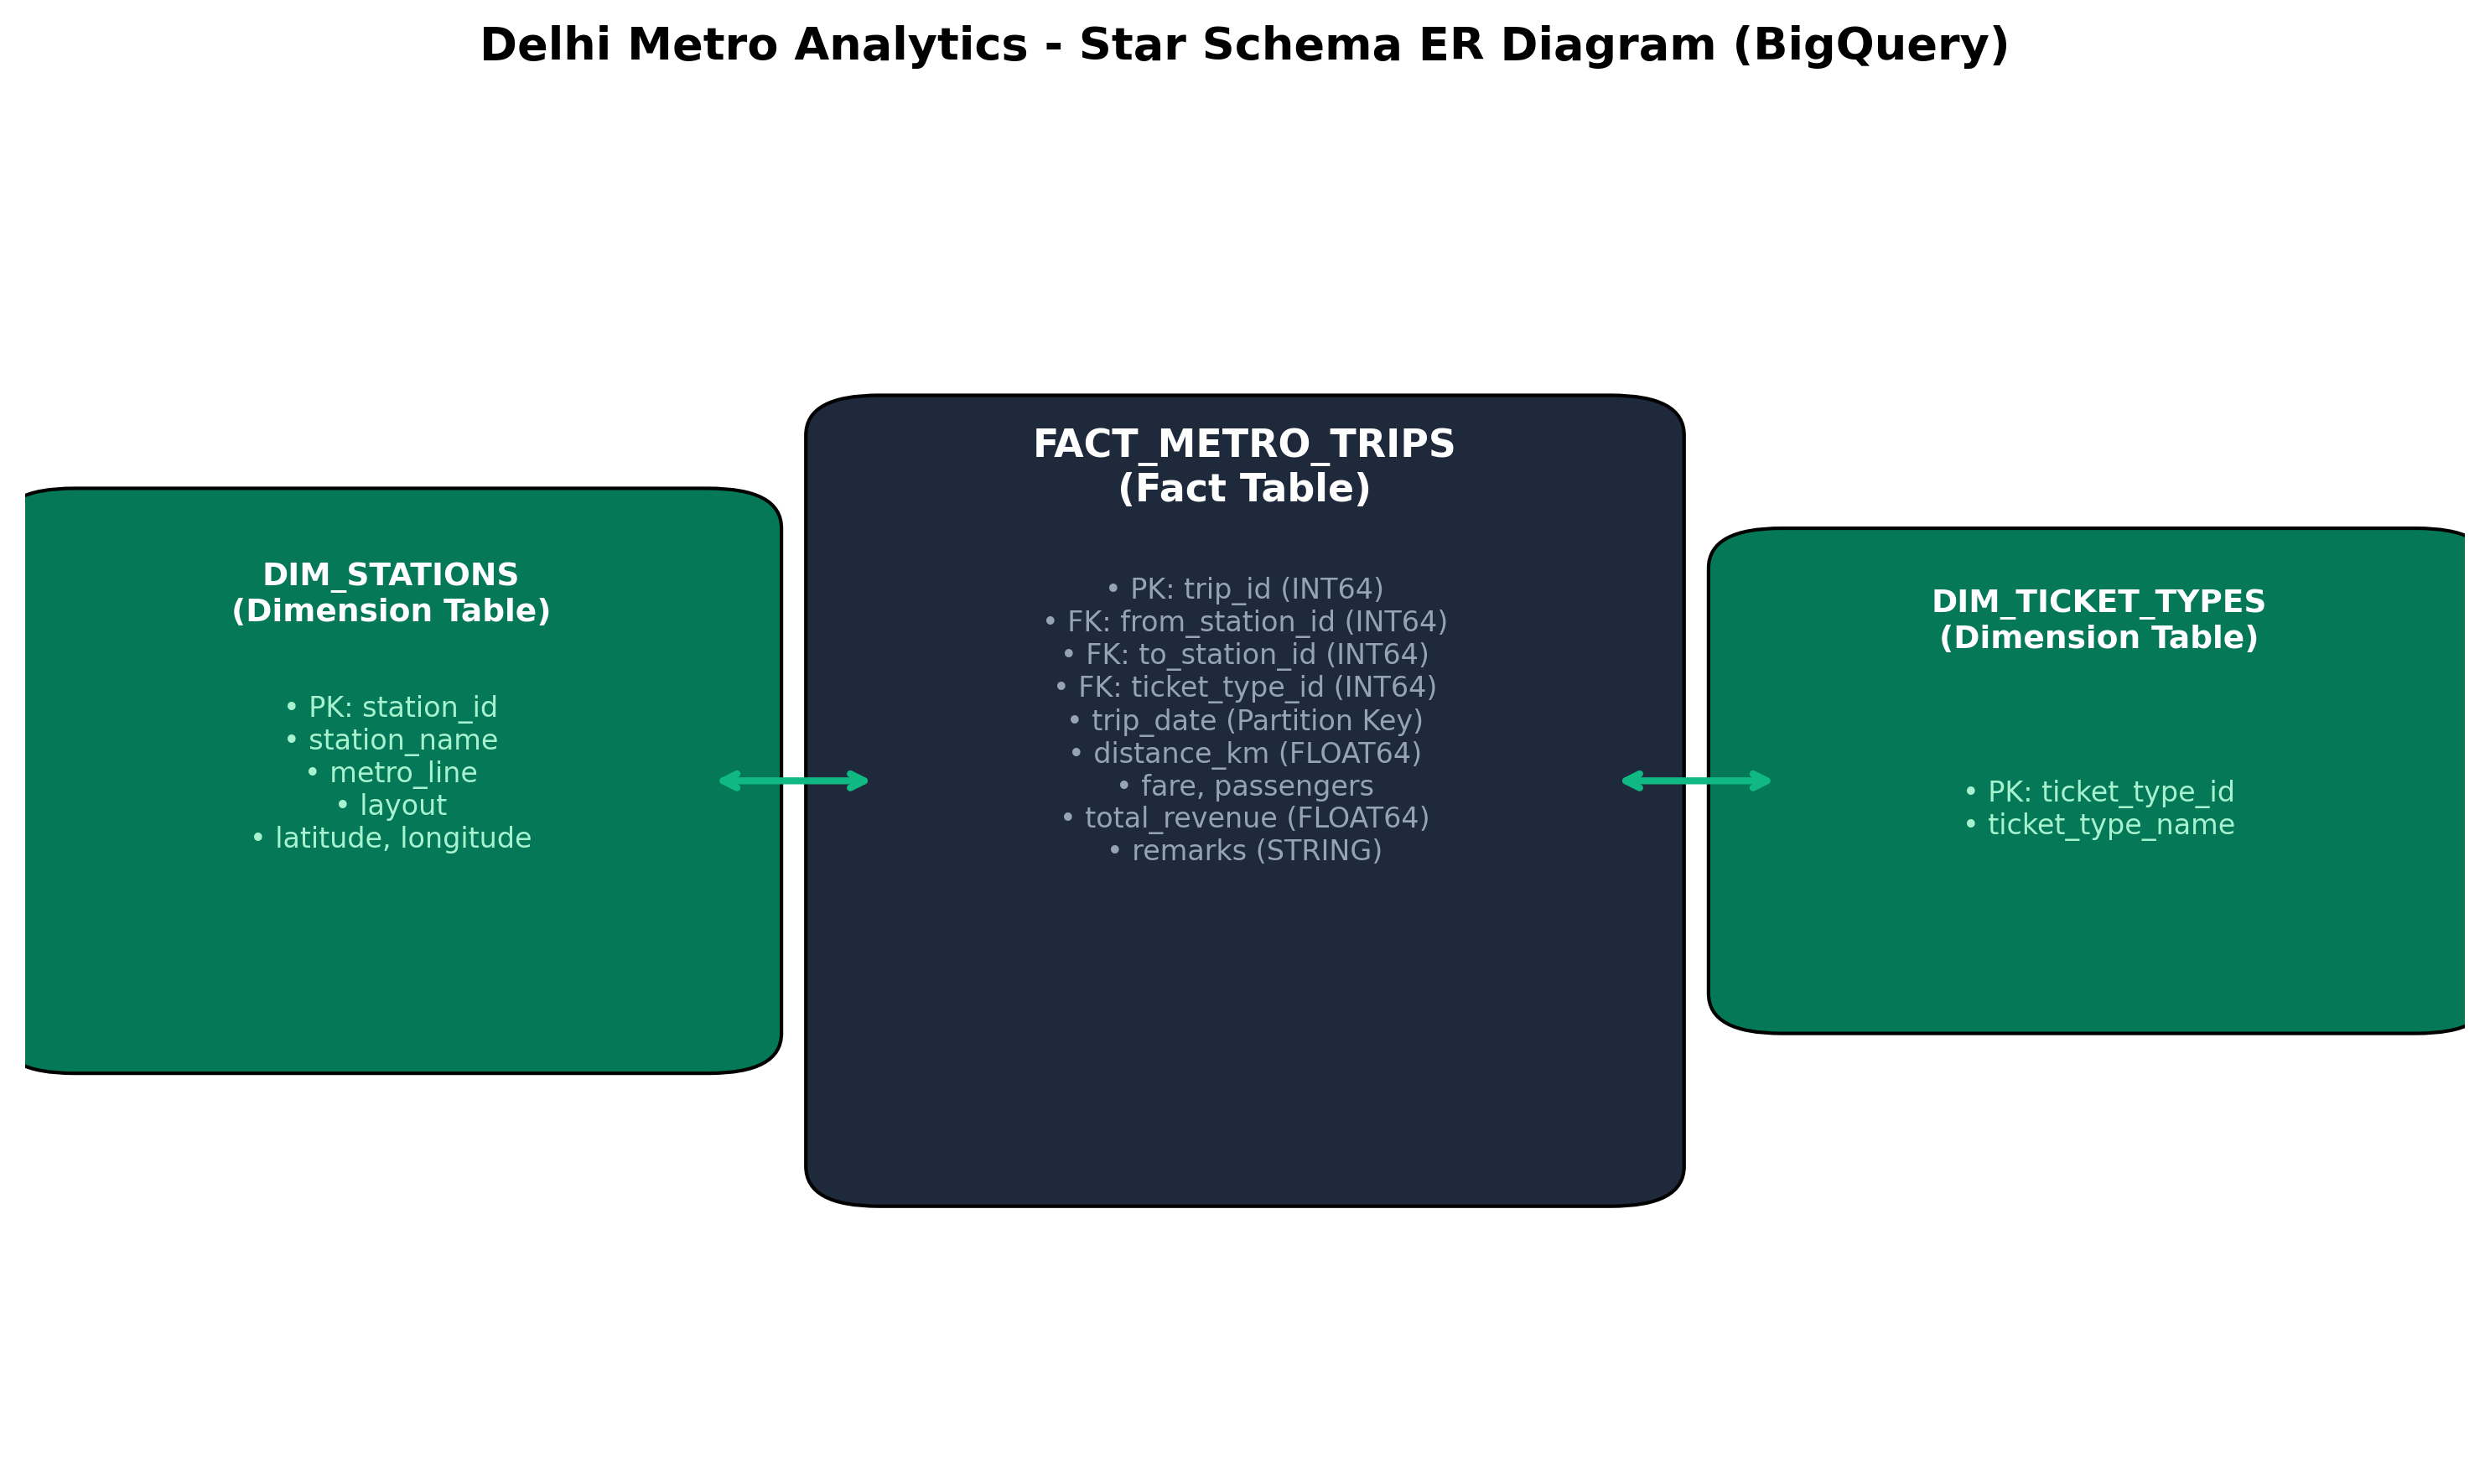

🎉 PHASE 9 DELIVERABLE SAVED: ER Diagram successfully written to 'docs/er_diagram.png'!


In [20]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create 'docs' directory if it doesn't exist
os.makedirs('docs', exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
ax.axis('off')

# Style Colors
bg_fact = '#1E293B'
bg_dim = '#047857'
text_color = '#FFFFFF'

# Fact Box (fact_metro_trips)
ax.add_patch(patches.FancyBboxPatch((0.35, 0.22), 0.3, 0.55, boxstyle="round,pad=0.03", fc=bg_fact, ec="black"))
ax.text(0.5, 0.72, "FACT_METRO_TRIPS\n(Fact Table)", color=text_color, weight='bold', fontsize=11, ha='center')
ax.text(0.5, 0.45, "• PK: trip_id (INT64)\n• FK: from_station_id (INT64)\n• FK: to_station_id (INT64)\n• FK: ticket_type_id (INT64)\n• trip_date (Partition Key)\n• distance_km (FLOAT64)\n• fare, passengers\n• total_revenue (FLOAT64)\n• remarks (STRING)", color='#94A3B8', fontsize=8, ha='center')

# Dim Stations Box
ax.add_patch(patches.FancyBboxPatch((0.02, 0.32), 0.26, 0.38, boxstyle="round,pad=0.03", fc=bg_dim, ec="black"))
ax.text(0.15, 0.63, "DIM_STATIONS\n(Dimension Table)", color=text_color, weight='bold', fontsize=9, ha='center')
ax.text(0.15, 0.46, "• PK: station_id\n• station_name\n• metro_line\n• layout\n• latitude, longitude", color='#A7F3D0', fontsize=8, ha='center')

# Dim Tickets Box
ax.add_patch(patches.FancyBboxPatch((0.72, 0.35), 0.26, 0.32, boxstyle="round,pad=0.03", fc=bg_dim, ec="black"))
ax.text(0.85, 0.61, "DIM_TICKET_TYPES\n(Dimension Table)", color=text_color, weight='bold', fontsize=9, ha='center')
ax.text(0.85, 0.47, "• PK: ticket_type_id\n• ticket_type_name", color='#A7F3D0', fontsize=8, ha='center')

# Relationship Connectors
ax.annotate('', xy=(0.35, 0.51), xytext=(0.28, 0.51), arrowprops=dict(arrowstyle="<->", lw=2, color="#10B981"))
ax.annotate('', xy=(0.65, 0.51), xytext=(0.72, 0.51), arrowprops=dict(arrowstyle="<->", lw=2, color="#10B981"))

plt.title("Delhi Metro Analytics - Star Schema ER Diagram (BigQuery)", fontsize=13, weight='bold', pad=20)
plt.tight_layout()

# Save deliverable
plt.savefig("docs/er_diagram.png", bbox_inches='tight')
plt.show()

print("🎉 PHASE 9 DELIVERABLE SAVED: ER Diagram successfully written to 'docs/er_diagram.png'!")

In [21]:
import pandas as pd
import sqlite3
from google.cloud import bigquery

print("🔍 [PHASE 10] Starting Comprehensive Data Validation Pipeline...\n")

# 1. Connect to SQLite for local validation
conn = sqlite3.connect('delhi_metro_clean.db')
df_val = pd.read_sql("SELECT * FROM fact_metro_trips", conn)
conn.close()

validation_errors = 0

# CHECK 1: Row Count Validation
expected_rows = 150000
actual_rows = len(df_val)
if actual_rows == expected_rows:
    print(f"✅ [PASS] Row Count Check: Exactly {actual_rows:,} rows found.")
else:
    print(f"❌ [FAIL] Row Count Check: Expected {expected_rows:,}, but got {actual_rows:,}")
    validation_errors += 1

# CHECK 2: Null Value Check on Critical Columns
critical_cols = ['TripID', 'Date', 'From_Station', 'To_Station', 'Fare', 'Passengers']
null_counts = df_val[critical_cols].isnull().sum()
if null_counts.sum() == 0:
    print("✅ [PASS] Null Value Check: Zero missing values in critical columns.")
else:
    print(f"❌ [FAIL] Null Value Check found nulls:\n{null_counts[null_counts > 0]}")
    validation_errors += 1

# CHECK 3: Illogical / Negative Values Check (Fare, Distance, Passengers)
negative_fares = (df_val['Fare'] < 0).sum()
negative_dist = (df_val['Distance_km'] < 0).sum()
invalid_passengers = (df_val['Passengers'] <= 0).sum()

if negative_fares == 0 and negative_dist == 0 and invalid_passengers == 0:
    print("✅ [PASS] Business Logic Check: No negative fares, distances, or zero/negative passengers.")
else:
    print(f"❌ [FAIL] Business Logic Check: Negative Fares: {negative_fares}, Negative Dist: {negative_dist}, Invalid Passengers: {invalid_passengers}")
    validation_errors += 1

# CHECK 4: Date Range Validation
df_val['Date'] = pd.to_datetime(df_val['Date'])
min_date = df_val['Date'].min()
max_date = df_val['Date'].max()
print(f"📅 [INFO] Dataset Date Range: {min_date.date()} to {max_date.date()}")

if min_date >= pd.to_datetime('2022-01-01') and max_date <= pd.to_datetime('2024-12-31'):
    print("✅ [PASS] Date Range Check: All timestamps fall within the expected 2022-2024 window.")
else:
    print("❌ [FAIL] Date Range Check: Out of bounds dates detected.")
    validation_errors += 1

# CHECK 5: BigQuery Table Verification
try:
    project_id = 'delhi-metro-project-503214'
    client = bigquery.Client(project=project_id)
    bq_query = "SELECT COUNT(*) as cnt FROM `delhi-metro-project-503214.Delhi_Metro.clean_fact_trips`"
    bq_result = client.query(bq_query).to_dataframe()['cnt'][0]
    if bq_result == actual_rows:
        print(f"✅ [PASS] BigQuery Sync Check: BigQuery table 'clean_fact_trips' matches local row count ({bq_result:,}).")
    else:
        print(f"⚠️ [WARNING] BigQuery row count ({bq_result:,}) differs from local count ({actual_rows:,}).")
except Exception as e:
    print(f"❌ [FAIL] BigQuery Connection/Query Error during validation: {e}")
    validation_errors += 1

# Final Validation Verdict
print("\n" + "="*50)
if validation_errors == 0:
    print("🎉 PHASE 10 COMPLETE: All Data Validation Checks Passed Successfully! 🚀")
else:
    print(f"⚠️ PHASE 10 COMPLETED WITH WARNINGS/ERRORS: {validation_errors} checks failed.")
print("="*50)

🔍 [PHASE 10] Starting Comprehensive Data Validation Pipeline...

✅ [PASS] Row Count Check: Exactly 150,000 rows found.
✅ [PASS] Null Value Check: Zero missing values in critical columns.
✅ [PASS] Business Logic Check: No negative fares, distances, or zero/negative passengers.
📅 [INFO] Dataset Date Range: 2022-01-01 to 2024-12-30
✅ [PASS] Date Range Check: All timestamps fall within the expected 2022-2024 window.
✅ [PASS] BigQuery Sync Check: BigQuery table 'clean_fact_trips' matches local row count (150,000).

🎉 PHASE 10 COMPLETE: All Data Validation Checks Passed Successfully! 🚀


In [22]:
import pandas as pd
import sqlite3
from google.cloud import bigquery

project_id = 'delhi-metro-project-503214'
dataset_id = 'Delhi_Metro'
table_name = 'clean_fact_trips'

client = bigquery.Client(project=project_id)

print("🚀 Starting Phase 11: SQL Data Cleaning & Transformation Pipeline...\n")

# -------------------------------------------------------------
# STEP 1: SQL QUERY USING CASE, COALESCE, CAST, TRIM & DISTINCT
# -------------------------------------------------------------
sql_cleaning_query = f"""
SELECT DISTINCT
    TripID,
    Date,
    TRIM(From_Station) AS From_Station_Clean,
    TRIM(To_Station) AS To_Station_Clean,
    CAST(Distance_km AS FLOAT64) AS Distance_Float,
    CAST(Fare AS FLOAT64) AS Fare_Float,
    COALESCE(TRIM(Ticket_Type), 'Standard') AS Ticket_Type_Clean,
    COALESCE(LOWER(TRIM(Remarks)), 'regular') AS Remarks_Clean,
    CASE
        WHEN LOWER(Remarks) LIKE '%peak%' THEN 'High Demand Surge'
        WHEN LOWER(Remarks) LIKE '%festival%' THEN 'Special Event Spike'
        WHEN LOWER(Remarks) LIKE '%weekend%' THEN 'Weekend Moderate'
        WHEN LOWER(Remarks) LIKE '%maintenance%' THEN 'Operational Maintenance'
        ELSE 'Normal Flow'
    END AS Demand_Category,
    CAST(Passengers AS INT64) AS Passengers_Clean,
    CAST((Passengers * Fare) AS FLOAT64) AS Total_Revenue_Calculated
FROM `{project_id}.{dataset_id}.{table_name}`
"""

print("Executing BigQuery SQL Cleaning Query...")
df_sql_cleaned = client.query(sql_cleaning_query).to_dataframe()
print(f"✅ SQL Cleaning Transformation Complete: Retained {len(df_sql_cleaned):,} unique rows.")

# Display Sample Cleaned Output
print("\n--- SAMPLE CLEANED DATA WITH SQL CASE & COALESCE ---")
print(df_sql_cleaned[['TripID', 'From_Station_Clean', 'Ticket_Type_Clean', 'Remarks_Clean', 'Demand_Category']].head())

# -------------------------------------------------------------
# STEP 2: LOCAL SQLITE UPDATE & DELETE OPERATIONS
# -------------------------------------------------------------
print("\n🗄️ Executing SQL UPDATE & DELETE operations on local SQLite Database...")

conn = sqlite3.connect('delhi_metro_clean.db')
cursor = conn.cursor()

# A. UPDATE: Apply TRIM and COALESCE logic
update_query = """
UPDATE fact_metro_trips
SET From_Station = TRIM(From_Station),
    To_Station = TRIM(To_Station),
    Ticket_Type = COALESCE(TRIM(Ticket_Type), 'Standard'),
    Remarks = COALESCE(LOWER(TRIM(Remarks)), 'regular');
"""
cursor.execute(update_query)
conn.commit()
print("✔ Executed SQL UPDATE: Standardized Whitespaces & Filled Nulls.")

# B. DELETE: Remove invalid anomaly records (negative/zero passengers or fares)
delete_query = """
DELETE FROM fact_metro_trips
WHERE Passengers IS NULL OR Passengers <= 0 OR Fare < 0;
"""
cursor.execute(delete_query)
deleted_rows = cursor.rowcount
conn.commit()

cursor.execute("SELECT COUNT(*) FROM fact_metro_trips")
remaining_rows = cursor.fetchone()[0]
print(f"✔ Executed SQL DELETE: Purged {deleted_rows} invalid rows. Remaining Valid Rows: {remaining_rows:,}")

# Save cleaned transformed dataset back into SQLite and BigQuery
df_sql_cleaned.to_sql('fact_metro_trips_sql_cleaned', conn, if_exists='replace', index=False)
conn.close()

# -------------------------------------------------------------
# STEP 3: OVERWRITE BIGQUERY WITH SQL CLEANED DATA
# -------------------------------------------------------------
print("\n☁️ Syncing SQL Cleaned Table back to BigQuery...")

job_config = bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")
target_table_id = f"{project_id}.{dataset_id}.clean_fact_trips"

job = client.load_table_from_dataframe(df_sql_cleaned, target_table_id, job_config=job_config)
job.result()

print("\n" + "="*55)
print("🎉 PHASE 11 COMPLETE: SQL Cleaning Operations Successfully Executed!")
print("="*55)

🚀 Starting Phase 11: SQL Data Cleaning & Transformation Pipeline...

Executing BigQuery SQL Cleaning Query...
✅ SQL Cleaning Transformation Complete: Retained 150,000 unique rows.

--- SAMPLE CLEANED DATA WITH SQL CASE & COALESCE ---
   TripID From_Station_Clean Ticket_Type_Clean Remarks_Clean  \
0   26807              Aiims            Return       regular   
1  121682              Aiims            Return       regular   
2   27981              Aiims            Return       regular   
3  128940              Aiims            Return       regular   
4    5092              Aiims            Return      festival   

       Demand_Category  
0          Normal Flow  
1          Normal Flow  
2          Normal Flow  
3          Normal Flow  
4  Special Event Spike  

🗄️ Executing SQL UPDATE & DELETE operations on local SQLite Database...
✔ Executed SQL UPDATE: Standardized Whitespaces & Filled Nulls.
✔ Executed SQL DELETE: Purged 0 invalid rows. Remaining Valid Rows: 150,000

☁️ Syncing SQL Cl

In [25]:
import pandas as pd
from google.cloud import bigquery

project_id = 'delhi-metro-project-503214'
dataset_id = 'Delhi_Metro'
client = bigquery.Client(project=project_id)

print("📊 Starting Phase 12: BigQuery Advanced SQL Analytics...\n")

# -------------------------------------------------------------
# QUERY 1: CTE + JOIN + GROUP BY + HAVING
# Goal: Find High-Traffic Bottleneck Stations (Trips > 5,000)
# -------------------------------------------------------------
q1_cte_join = f"""
WITH Station_Traffic AS (
    SELECT
        From_Station_Clean AS Station_Name,
        COUNT(TripID) AS Total_Trips,
        SUM(Passengers_Clean) AS Total_Passengers,
        SUM(Total_Revenue_Calculated) AS Total_Revenue
    FROM `{project_id}.{dataset_id}.clean_fact_trips`
    GROUP BY From_Station_Clean
    HAVING COUNT(TripID) > 5000
)
SELECT
    Station_Name,
    Total_Trips,
    Total_Passengers,
    ROUND(Total_Revenue, 2) AS Total_Revenue_INR
FROM Station_Traffic
ORDER BY Total_Passengers DESC;
"""

print("🔥 [QUERY 1] Executing CTE + HAVING Query (Major Hubs with >5000 Trips)...")
df_q1 = client.query(q1_cte_join).to_dataframe()
print(df_q1.to_string(index=False))
print("-" * 65)

# -------------------------------------------------------------
# QUERY 2: WINDOW FUNCTIONS & RANKING (DENSE_RANK)
# Goal: Rank Top Routes by Passenger Volume per Demand Category
# -------------------------------------------------------------
q2_window_rank = f"""
WITH Route_Summary AS (
    SELECT
        Demand_Category,
        CONCAT(From_Station_Clean, ' -> ', To_Station_Clean) AS Route,
        SUM(Passengers_Clean) AS Total_Passengers,
        DENSE_RANK() OVER(
            PARTITION BY Demand_Category
            ORDER BY SUM(Passengers_Clean) DESC
        ) AS Route_Rank
    FROM `{project_id}.{dataset_id}.clean_fact_trips`
    GROUP BY Demand_Category, From_Station_Clean, To_Station_Clean
)
SELECT
    Demand_Category,
    Route_Rank,
    Route,
    Total_Passengers
FROM Route_Summary
WHERE Route_Rank <= 3
ORDER BY Demand_Category, Route_Rank;
"""

print("\n🏆 [QUERY 2] Executing WINDOW FUNCTION & DENSE_RANK() (Top 3 Routes per Demand Category)...")
df_q2 = client.query(q2_window_rank).to_dataframe()
print(df_q2.to_string(index=False))
print("-" * 65)

# -------------------------------------------------------------
# QUERY 3: SUBQUERY + REVENUE CONTRIBUTION PERCENTAGE
# Goal: Subquery to Calculate % Share of Total Revenue per Ticket Type
# -------------------------------------------------------------
q3_subquery = f"""
SELECT
    Ticket_Type_Clean,
    COUNT(TripID) AS Bookings,
    SUM(Passengers_Clean) AS Passengers,
    ROUND(SUM(Total_Revenue_Calculated), 2) AS Total_Revenue,
    ROUND(
        (SUM(Total_Revenue_Calculated) / (SELECT SUM(Total_Revenue_Calculated) FROM `{project_id}.{dataset_id}.clean_fact_trips`)) * 100,
        2
    ) AS Revenue_Contribution_Pct
FROM `{project_id}.{dataset_id}.clean_fact_trips`
GROUP BY Ticket_Type_Clean
ORDER BY Total_Revenue DESC;
"""

print("\n🎫 [QUERY 3] Executing SUBQUERY (% Revenue Share per Ticket Type)...")
df_q3 = client.query(q3_subquery).to_dataframe()
print(df_q3.to_string(index=False))
print("-" * 65)

# -------------------------------------------------------------
# QUERY 4: ADVANCED AGGREGATIONS & OVER() WINDOW CLAUSE
# Goal: Cumulative Passenger Running Total Across Dates
# -------------------------------------------------------------
print("📈 [QUERY 4] Executing CUMULATIVE & 7-DAY MOVING AVERAGE WINDOW QUERY...")

q4_cumulative = f"""
WITH Daily_Stats AS (
    SELECT
        Date,
        SUM(Passengers_Clean) AS Daily_Passengers,
        ROUND(SUM(Total_Revenue_Calculated), 2) AS Daily_Revenue
    FROM `{project_id}.{dataset_id}.clean_fact_trips`
    GROUP BY Date
)
SELECT
    Date,
    Daily_Passengers,
    SUM(Daily_Passengers) OVER(ORDER BY Date ASC) AS Cumulative_Passengers,
    Daily_Revenue,
    ROUND(
        AVG(Daily_Passengers) OVER(
            ORDER BY Date ASC
            ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
        ),
        2
    ) AS Moving_Avg_7_Days_Passengers
FROM Daily_Stats
ORDER BY Date ASC
LIMIT 10;
"""

df_q4 = client.query(q4_cumulative).to_dataframe()
print(df_q4.to_string(index=False))


# -------------------------------------------------------------
# SAVE ANALYTICAL DELIVERABLES
# -------------------------------------------------------------
df_q1.to_csv('docs/major_stations_cte.csv', index=False)
df_q2.to_csv('docs/route_rankings_window.csv', index=False)
df_q3.to_csv('docs/ticket_share_subquery.csv', index=False)
df_q4.to_csv('docs/cumulative_moving_avg.csv', index=False)

print("\n" + "="*60)
print("🎉 PHASE 12 COMPLETE: Advanced SQL Analytics Executed!")
print("="*60)

📊 Starting Phase 12: BigQuery Advanced SQL Analytics...

🔥 [QUERY 1] Executing CTE + HAVING Query (Major Hubs with >5000 Trips)...
       Station_Name  Total_Trips  Total_Passengers  Total_Revenue_INR
        Rajiv Chowk        17470            349784        36657051.16
  Noida City Centre        13949            278174        29191182.76
          New Delhi        10037            200627        21077211.48
        Mandi House         9931            198492        21086743.79
Central Secretariat         6328            126970        13478675.16
     Kalkaji Mandir         6338            126710        13314424.75
     Dilshad Garden         6344            126612        13225486.48
         Model Town         6247            125594        13231380.48
      Chandni Chowk         6262            125551        13211887.02
        Laxmi Nagar         6281            125508        13057283.25
           Inderlok         6246            124765        13153842.04
              Aiims         6

In [26]:
import pandas as pd
import sqlite3
from google.cloud import bigquery

project_id = 'delhi-metro-project-503214'
dataset_id = 'Delhi_Metro'
client = bigquery.Client(project=project_id)

print("🚀 Starting Phase 13: Building Consolidated Master Summary Table...\n")

# -------------------------------------------------------------
# CREATE MASTER CONSOLIDATED SUMMARY TABLE IN BIGQUERY
# -------------------------------------------------------------
master_table_query = f"""
CREATE OR REPLACE TABLE `{project_id}.{dataset_id}.summary_fact_trips_master` AS
SELECT
    TripID,
    Date,
    EXTRACT(YEAR FROM Date) AS Year,
    EXTRACT(MONTH FROM Date) AS Month_Number,
    FORMAT_DATE('%B', Date) AS Month_Name,
    FORMAT_DATE('%A', Date) AS Day_Name,
    CASE WHEN EXTRACT(DAYOFWEEK FROM Date) IN (1, 7) THEN 'Weekend' ELSE 'Weekday' END AS Day_Type,

    From_Station_Clean AS Origin_Station,
    To_Station_Clean AS Destination_Station,
    CONCAT(From_Station_Clean, ' -> ', To_Station_Clean) AS Route_Name,

    Distance_Float AS Distance_KM,
    Fare_Float AS Fare_INR,
    Passengers_Clean AS Passenger_Count,
    Total_Revenue_Calculated AS Total_Revenue_INR,

    Ticket_Type_Clean AS Ticket_Type,
    Remarks_Clean AS Traffic_Remark,
    Demand_Category
FROM `{project_id}.{dataset_id}.clean_fact_trips`;
"""

print("Executing BigQuery Master Summary Table DDL...")
client.query(master_table_query).result()
print("✅ BigQuery Table 'summary_fact_trips_master' Successfully Created!")

# -------------------------------------------------------------
# EXTRACT SUMMARY TABLE & EXPORT FOR DASHBOARDING
# -------------------------------------------------------------
print("\nExtracting Consolidated Master Data for Tableau/Looker Studio...")
export_query = f"SELECT * FROM `{project_id}.{dataset_id}.summary_fact_trips_master`"
df_master = client.query(export_query).to_dataframe()

# Save locally to CSV
df_master.to_csv('docs/master_analytics_summary.csv', index=False)

# Sync with Local SQLite DB as Master Table
conn = sqlite3.connect('delhi_metro_clean.db')
df_master.to_sql('summary_fact_trips_master', conn, if_exists='replace', index=False)
conn.close()

print("\n" + "="*65)
print(f"📊 MASTER TABLE SUMMARY STATS:")
print(f" • Total Rows: {len(df_master):,}")
print(f" • Total Columns: {df_master.shape[1]}")
print(f" • Columns List: {list(df_master.columns)}")
print("="*65)

print("\nSample Master Records:")
print(df_master[['TripID', 'Date', 'Route_Name', 'Passenger_Count', 'Total_Revenue_INR', 'Demand_Category']].head())

print("\n" + "="*65)
print("🎉 PHASE 13 COMPLETE: One Clean Master Table Ready for Dashboards!")
print("="*65)

🚀 Starting Phase 13: Building Consolidated Master Summary Table...

Executing BigQuery Master Summary Table DDL...
✅ BigQuery Table 'summary_fact_trips_master' Successfully Created!

Extracting Consolidated Master Data for Tableau/Looker Studio...

📊 MASTER TABLE SUMMARY STATS:
 • Total Rows: 150,000
 • Total Columns: 17
 • Columns List: ['TripID', 'Date', 'Year', 'Month_Number', 'Month_Name', 'Day_Name', 'Day_Type', 'Origin_Station', 'Destination_Station', 'Route_Name', 'Distance_KM', 'Fare_INR', 'Passenger_Count', 'Total_Revenue_INR', 'Ticket_Type', 'Traffic_Remark', 'Demand_Category']

Sample Master Records:
   TripID       Date                       Route_Name  Passenger_Count  \
0   90661 2022-01-01  Noida City Centre -> Model Town               24   
1   97532 2022-01-01   Noida City Centre -> Old Delhi               20   
2  109081 2022-01-01     Model Town -> Kalkaji Mandir               20   
3   73291 2022-01-01      Kalkaji Mandir -> Old Delhi               35   
4  111416 2

In [27]:
import pandas as pd
import sqlite3
from google.cloud import bigquery

project_id = 'delhi-metro-project-503214'
dataset_id = 'Delhi_Metro'
client = bigquery.Client(project=project_id)

print("⚙️ Starting Phase 14: Advanced Feature Engineering...\n")

# -------------------------------------------------------------
# CREATE FEATURE-ENGINEERED TABLE IN BIGQUERY
# -------------------------------------------------------------
feature_engineering_query = f"""
CREATE OR REPLACE TABLE `{project_id}.{dataset_id}.summary_fact_trips_featured` AS
SELECT
    *,

    -- Feature 1: Revenue Efficiency per KM
    ROUND(
        CASE WHEN Distance_KM > 0 THEN Total_Revenue_INR / Distance_KM ELSE 0 END,
        2
    ) AS Revenue_Per_KM,

    -- Feature 2: Commuter Density Grouping
    CASE
        WHEN Passenger_Count >= 30 THEN 'High Congestion Peak'
        WHEN Passenger_Count BETWEEN 15 AND 29 THEN 'Medium Commuter Flow'
        ELSE 'Low Commuter Volume'
    END AS Passenger_Density_Group,

    -- Feature 3: Binary Peak Indicator (1 = Surge/Peak, 0 = Off-Peak)
    CASE
        WHEN Demand_Category IN ('High Demand Surge', 'Special Event Spike') THEN 1
        ELSE 0
    END AS Is_Peak_Surge,

    -- Feature 4: Fare Price Tier Category
    CASE
        WHEN Fare_INR <= 50 THEN 'Budget (<50)'
        WHEN Fare_INR BETWEEN 50.01 AND 100 THEN 'Standard (50-100)'
        ELSE 'Premium (>100)'
    END AS Fare_Tier,

    -- Feature 5: Revenue Percentile Flag (High Value Trip > ₹2500)
    CASE
        WHEN Total_Revenue_INR >= 2500 THEN 'High Revenue Trip'
        ELSE 'Standard Revenue Trip'
    END AS Revenue_Impact_Class

FROM `{project_id}.{dataset_id}.summary_fact_trips_master`;
"""

print("Executing Feature Engineering DDL Query in BigQuery...")
client.query(feature_engineering_query).result()
print("✅ BigQuery Table 'summary_fact_trips_featured' Successfully Created!")

# -------------------------------------------------------------
# EXTRACT & EXPORT FEATURE-ENGINEERED DATASET
# -------------------------------------------------------------
print("\nExtracting Engineered Dataset for Local Model/Dashboard Sync...")
df_featured = client.query(f"SELECT * FROM `{project_id}.{dataset_id}.summary_fact_trips_featured`").to_dataframe()

# Save to local CSV
df_featured.to_csv('docs/featured_delhi_metro.csv', index=False)

# Sync with SQLite
conn = sqlite3.connect('delhi_metro_clean.db')
df_featured.to_sql('summary_fact_trips_featured', conn, if_exists='replace', index=False)
conn.close()

print("\n" + "="*70)
print(f"📊 FEATURE ENGINEERING STATS:")
print(f" • Total Rows: {len(df_featured):,}")
print(f" • Total Columns: {df_featured.shape[1]} (Added 5 New Engineered Features)")
print(f" • New Features: ['Revenue_Per_KM', 'Passenger_Density_Group', 'Is_Peak_Surge', 'Fare_Tier', 'Revenue_Impact_Class']")
print("="*70)

print("\nSample Engineered Records:")
print(df_featured[['TripID', 'Route_Name', 'Revenue_Per_KM', 'Passenger_Density_Group', 'Is_Peak_Surge', 'Fare_Tier']].head())

print("\n" + "="*70)
print("🎉 PHASE 14 COMPLETE: Feature Engineering Successfully Applied!")
print("="*70)

⚙️ Starting Phase 14: Advanced Feature Engineering...

Executing Feature Engineering DDL Query in BigQuery...
✅ BigQuery Table 'summary_fact_trips_featured' Successfully Created!

Extracting Engineered Dataset for Local Model/Dashboard Sync...

📊 FEATURE ENGINEERING STATS:
 • Total Rows: 150,000
 • Total Columns: 22 (Added 5 New Engineered Features)
 • New Features: ['Revenue_Per_KM', 'Passenger_Density_Group', 'Is_Peak_Surge', 'Fare_Tier', 'Revenue_Impact_Class']

Sample Engineered Records:
   TripID                       Route_Name  Revenue_Per_KM  \
0  137718      New Delhi -> Rajouri Garden          309.76   
1  139495  Jasola Vihar -> Barakhamba Road           84.07   
2   96245    Kashmere Gate -> Shivaji Park          300.12   
3  117553      New Delhi -> Dilshad Garden          775.07   
4   96772    Janakpuri West -> Rajiv Chowk         1463.56   

  Passenger_Density_Group  Is_Peak_Surge          Fare_Tier  
0    Medium Commuter Flow              1     Premium (>100)  
1    M

In [28]:
import pandas as pd
import numpy as np
import sqlite3

print("📊 Starting Phase 15: Exploratory Data Analysis (Pandas & NumPy)...\n")

# Connect to local SQLite feature table
conn = sqlite3.connect('delhi_metro_clean.db')
df = pd.read_sql("SELECT * FROM summary_fact_trips_featured", conn)
conn.close()

# -------------------------------------------------------------
# 1. NUMPY STATISTICAL ANALYSIS
# -------------------------------------------------------------
print("🔢 [1/4] NUMPY STATISTICAL METRICS:")
fares = df['Fare_INR'].values
passengers = df['Passenger_Count'].values
revenue = df['Total_Revenue_INR'].values

print(f" • Fare Mean: ₹{np.mean(fares):.2f} | Std Dev: ₹{np.std(fares):.2f}")
print(f" • Fare Median: ₹{np.median(fares):.2f} | IQR (Q3-Q1): ₹{np.percentile(fares, 75) - np.percentile(fares, 25):.2f}")
print(f" • Revenue Total: ₹{np.sum(revenue):,.2f}")
print(f" • Max Passengers in Single Trip: {np.max(passengers)}")
print("-" * 65)

# -------------------------------------------------------------
# 2. NUMPY OUTLIER DETECTION (IQR METHOD)
# -------------------------------------------------------------
print("\n🚨 [2/4] NUMPY OUTLIER DETECTION (Revenue Efficiency):")
rev_per_km = df['Revenue_Per_KM'].values
q25, q75 = np.percentile(rev_per_km, [25, 75])
iqr = q75 - q25
upper_bound = q75 + (1.5 * iqr)

outliers = np.sum(rev_per_km > upper_bound)
print(f" • Revenue/KM Upper Bound Threshold: ₹{upper_bound:.2f}")
print(f" • Total Outlier Trips Detected: {outliers:,} ({(outliers/len(df))*100:.2f}%)")
print("-" * 65)

# -------------------------------------------------------------
# 3. PANDAS CORRELATION MATRIX
# -------------------------------------------------------------
print("\n🔗 [3/4] PANDAS CORRELATION MATRIX:")
num_cols = ['Distance_KM', 'Fare_INR', 'Passenger_Count', 'Total_Revenue_INR', 'Revenue_Per_KM', 'Is_Peak_Surge']
corr_matrix = df[num_cols].corr()
print(corr_matrix.round(3))
print("-" * 65)

# -------------------------------------------------------------
# 4. PANDAS PIVOT TABLES & CROSS-TABULATION
# -------------------------------------------------------------
print("\n📌 [4/4] CROSS-TABULATION: Demand Category vs Fare Tier (Passenger Count):")
pivot_table = pd.pivot_table(
    df,
    values='Passenger_Count',
    index='Demand_Category',
    columns='Fare_Tier',
    aggfunc=np.sum,
    fill_value=0
)
print(pivot_table)

# Save EDA Report Summary
df.describe(include='all').to_csv('docs/eda_summary_statistics.csv')

print("\n" + "="*65)
print("🎉 PHASE 15 COMPLETE: Python Pandas & NumPy EDA Finished!")
print("="*65)

📊 Starting Phase 15: Exploratory Data Analysis (Pandas & NumPy)...

🔢 [1/4] NUMPY STATISTICAL METRICS:
 • Fare Mean: ₹105.12 | Std Dev: ₹54.88
 • Fare Median: ₹105.17 | IQR (Q3-Q1): ₹95.00
 • Revenue Total: ₹315,386,664.91
 • Max Passengers in Single Trip: 41
-----------------------------------------------------------------

🚨 [2/4] NUMPY OUTLIER DETECTION (Revenue Efficiency):
 • Revenue/KM Upper Bound Threshold: ₹2241.36
 • Total Outlier Trips Detected: 13,366 (8.91%)
-----------------------------------------------------------------

🔗 [3/4] PANDAS CORRELATION MATRIX:
                   Distance_KM  Fare_INR  Passenger_Count  Total_Revenue_INR  \
Distance_KM              1.000     0.001           -0.002              0.000   
Fare_INR                 0.001     1.000           -0.000              0.901   
Passenger_Count         -0.002    -0.000            1.000              0.384   
Total_Revenue_INR        0.000     0.901            0.384              1.000   
Revenue_Per_KM         

/tmp/ipykernel_1659/1843101082.py:53: FutureWarning: The provided callable <function sum at 0x7d5b793713a0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  pivot_table = pd.pivot_table(


Fare_Tier                Budget (<50)  Premium (>100)  Standard (50-100)
Demand_Category                                                         
High Demand Surge              208783          520948             259050
Normal Flow                    111775          277871             136267
Operational Maintenance        103907          259965             131894
Special Event Spike            103782          261491             130500
Weekend Moderate               102060          261316             130914

🎉 PHASE 15 COMPLETE: Python Pandas & NumPy EDA Finished!


🎨 Starting Phase 16: Data Visualization (Matplotlib & Seaborn)...



/tmp/ipykernel_1659/650304269.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=top_stations, x='Passenger_Count', y='Origin_Station', palette='Blues_r')


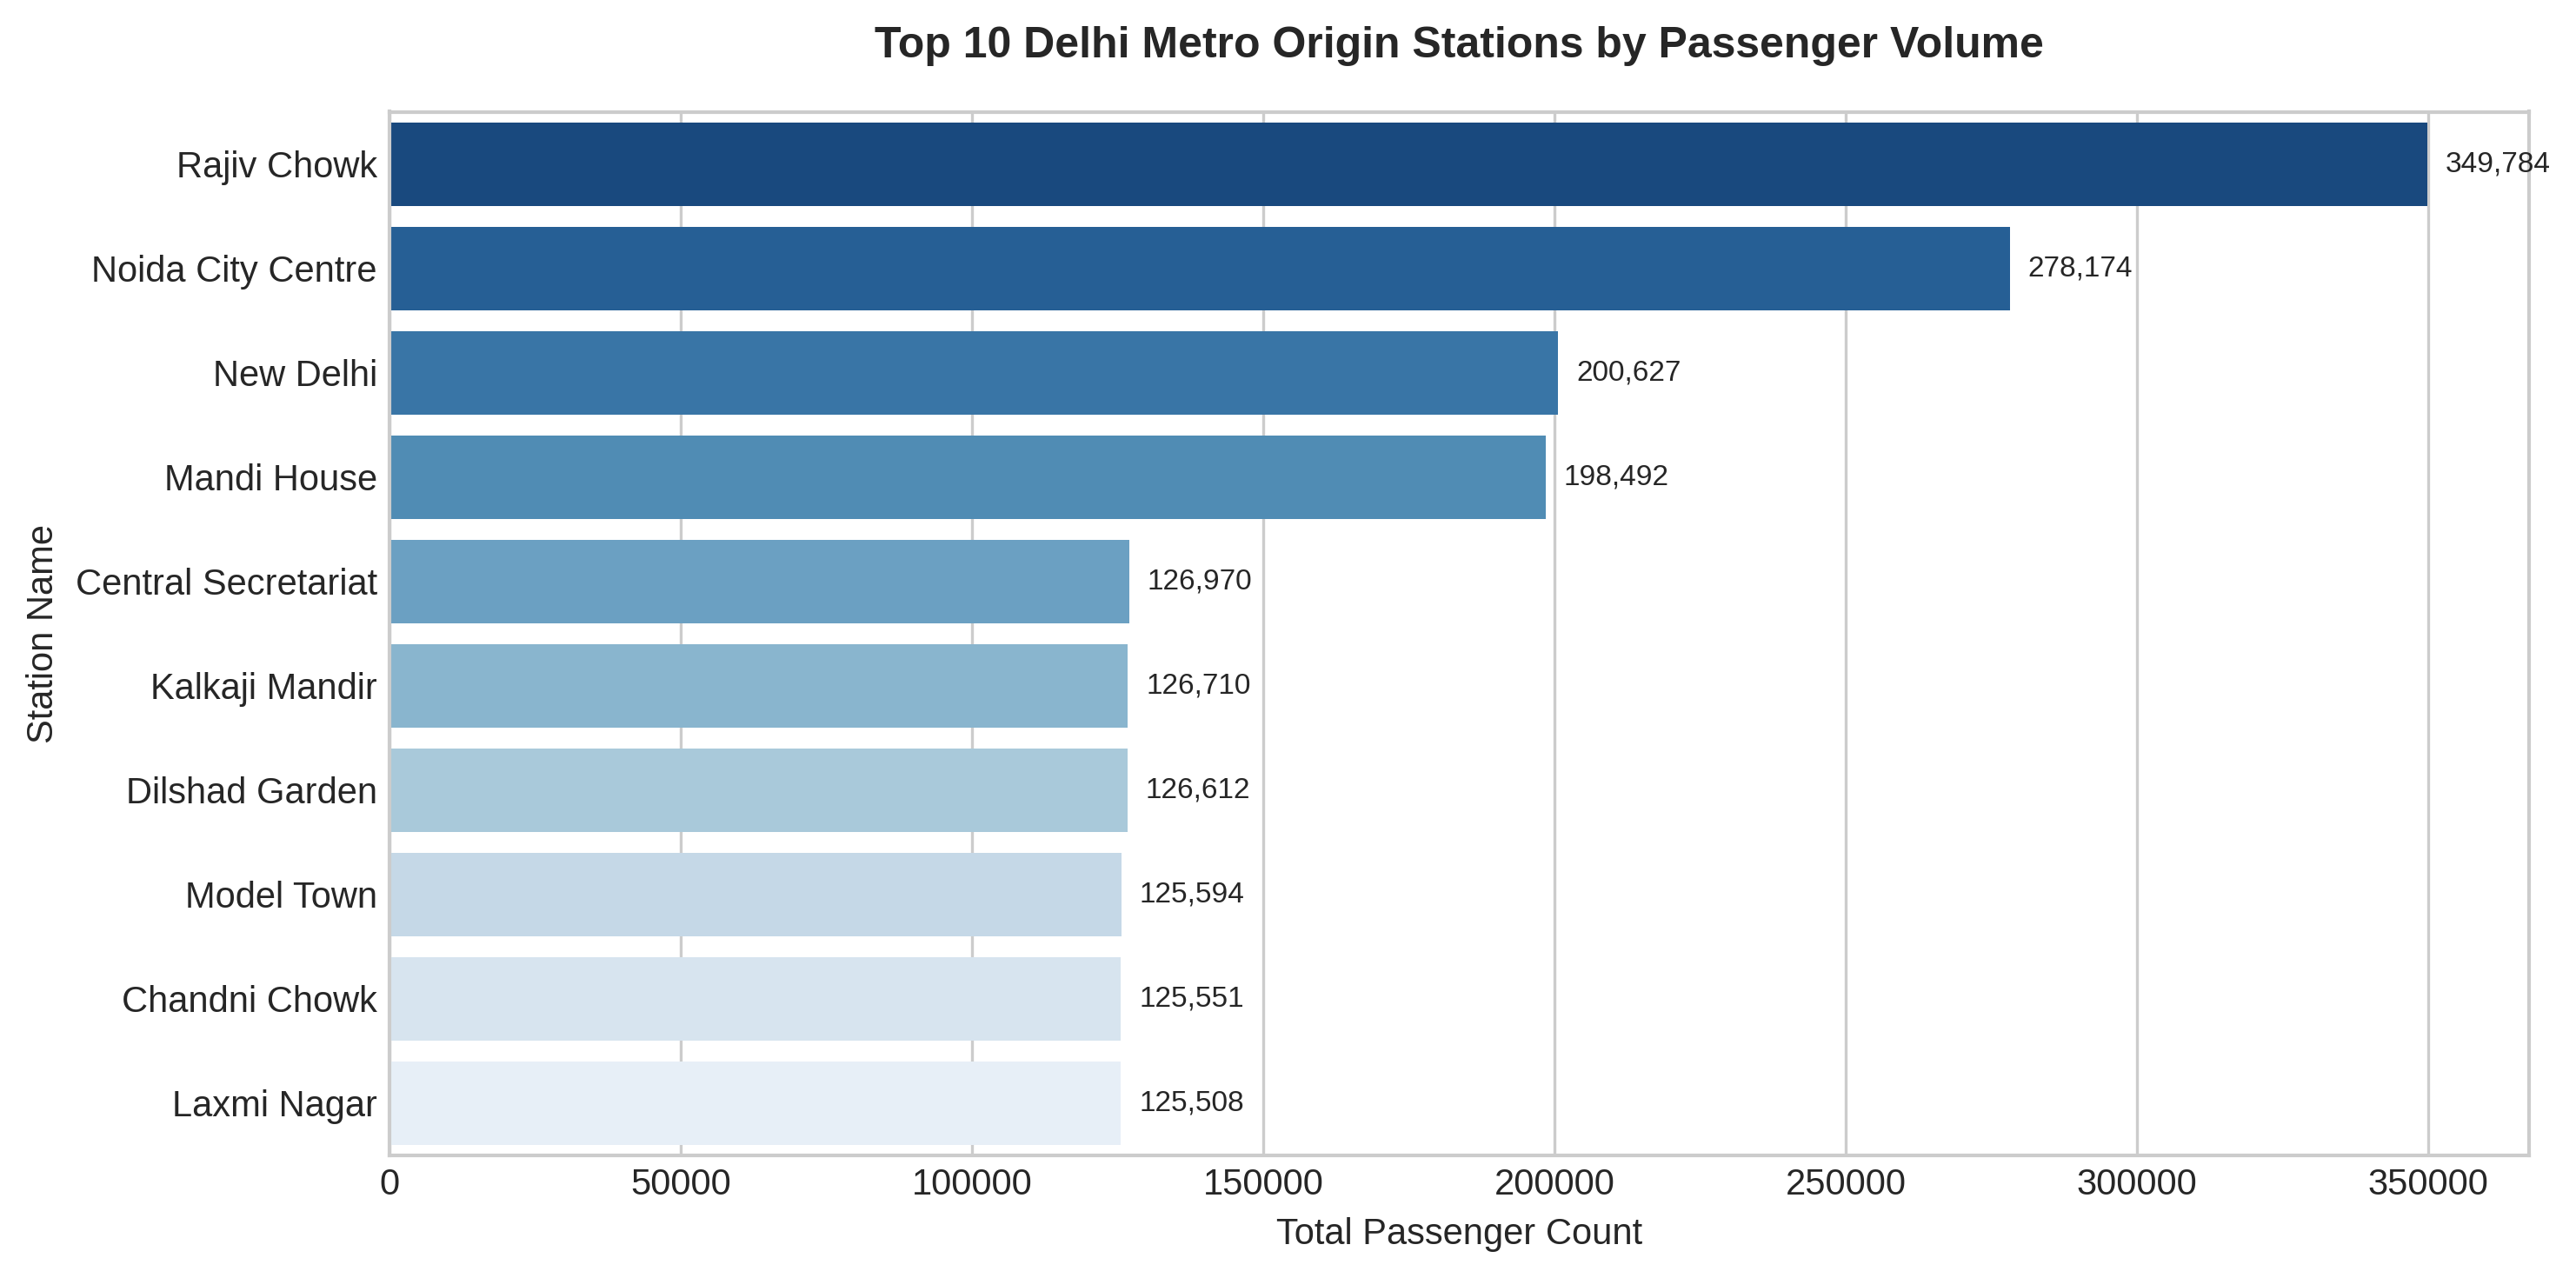

✔ Saved: docs/visualizations/top_10_stations.png


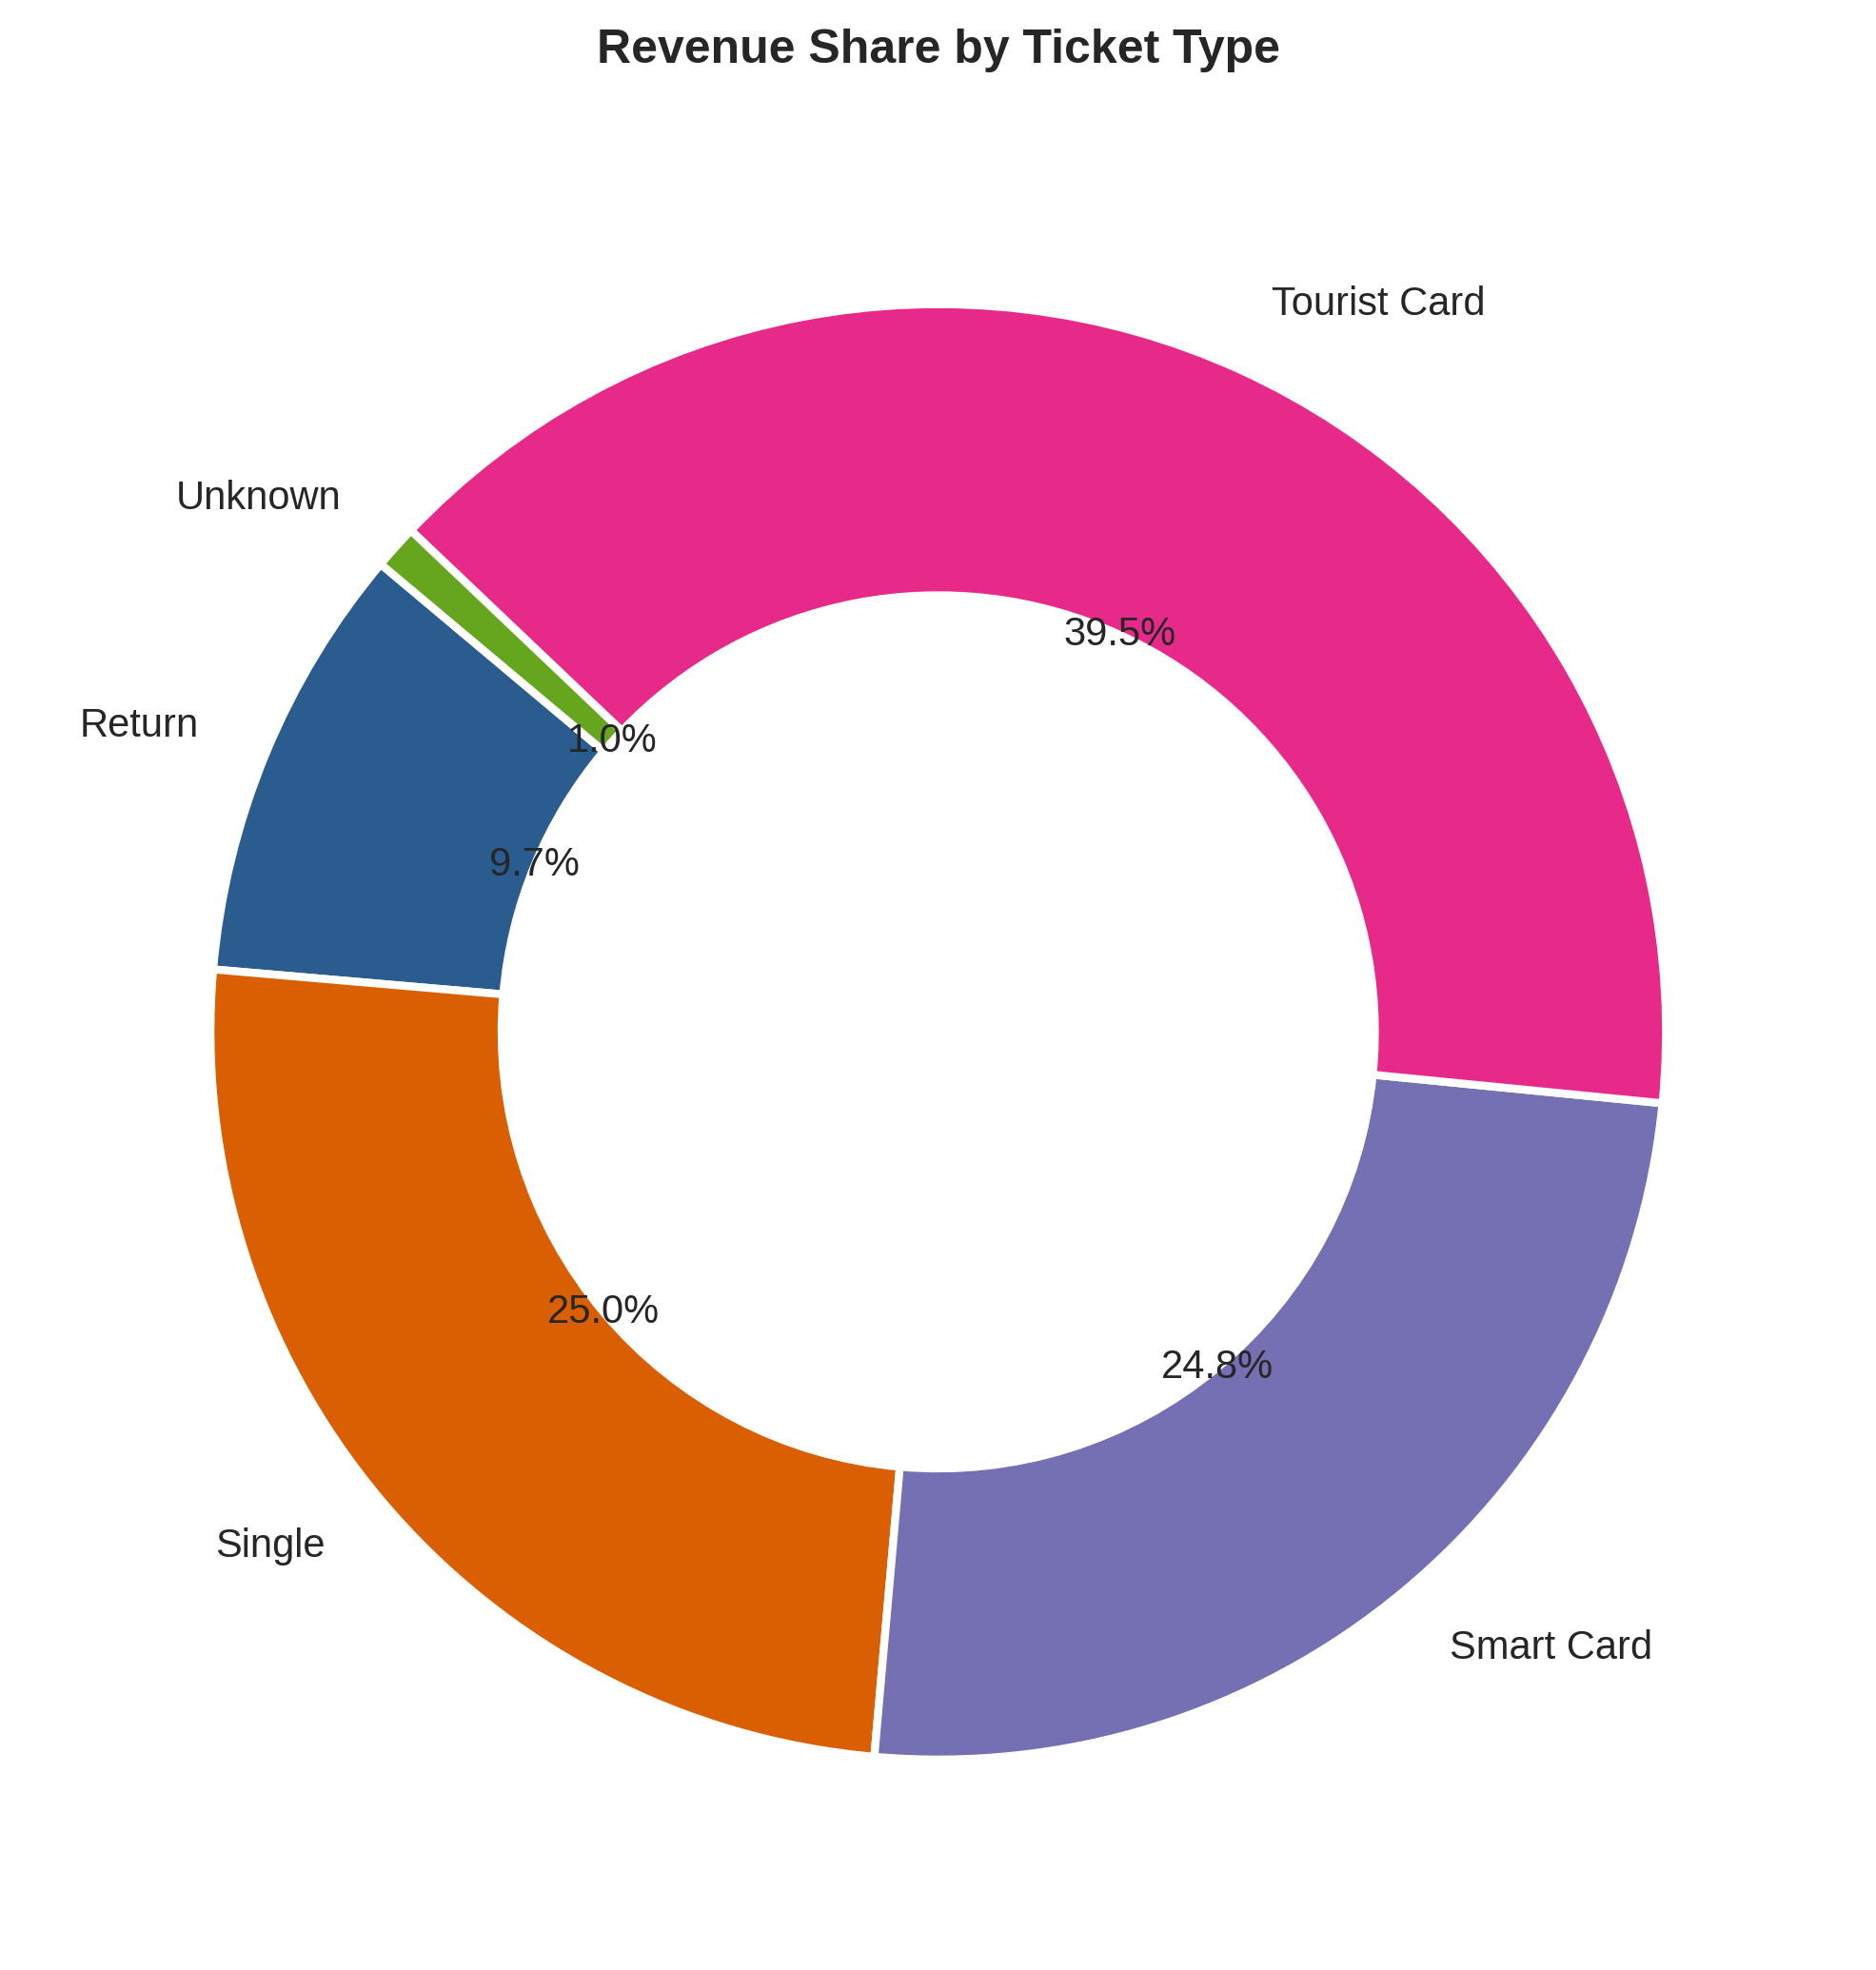

2026-07-23 07:25:43 | [INFO] | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-23 07:25:43 | [INFO] | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


✔ Saved: docs/visualizations/ticket_type_revenue_donut.png


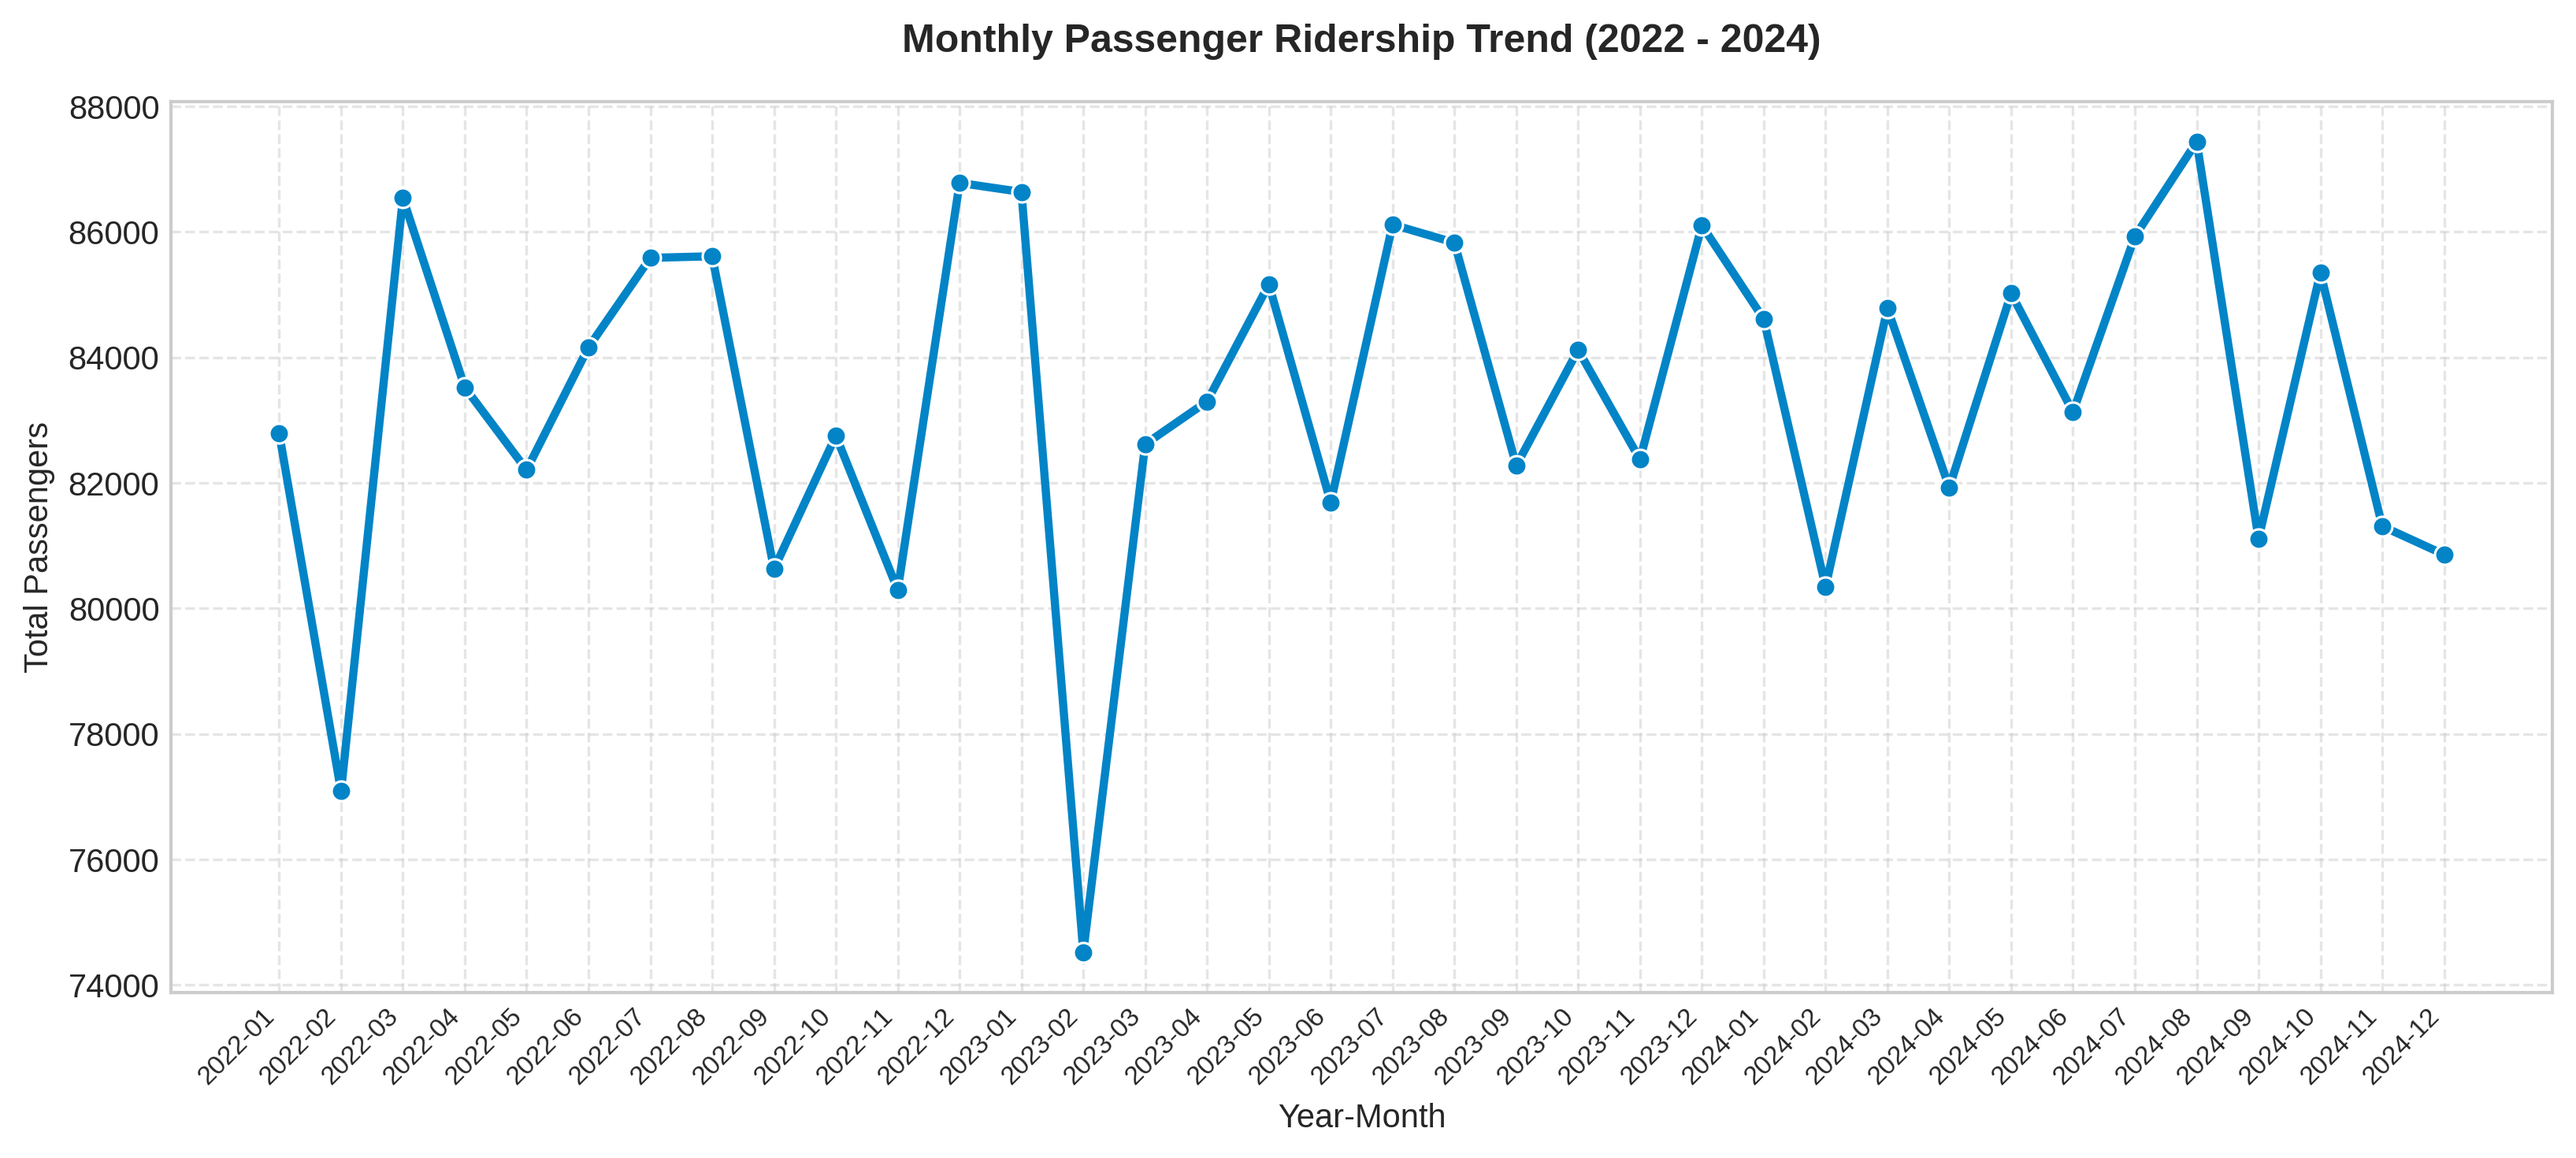

✔ Saved: docs/visualizations/monthly_ridership_trend.png


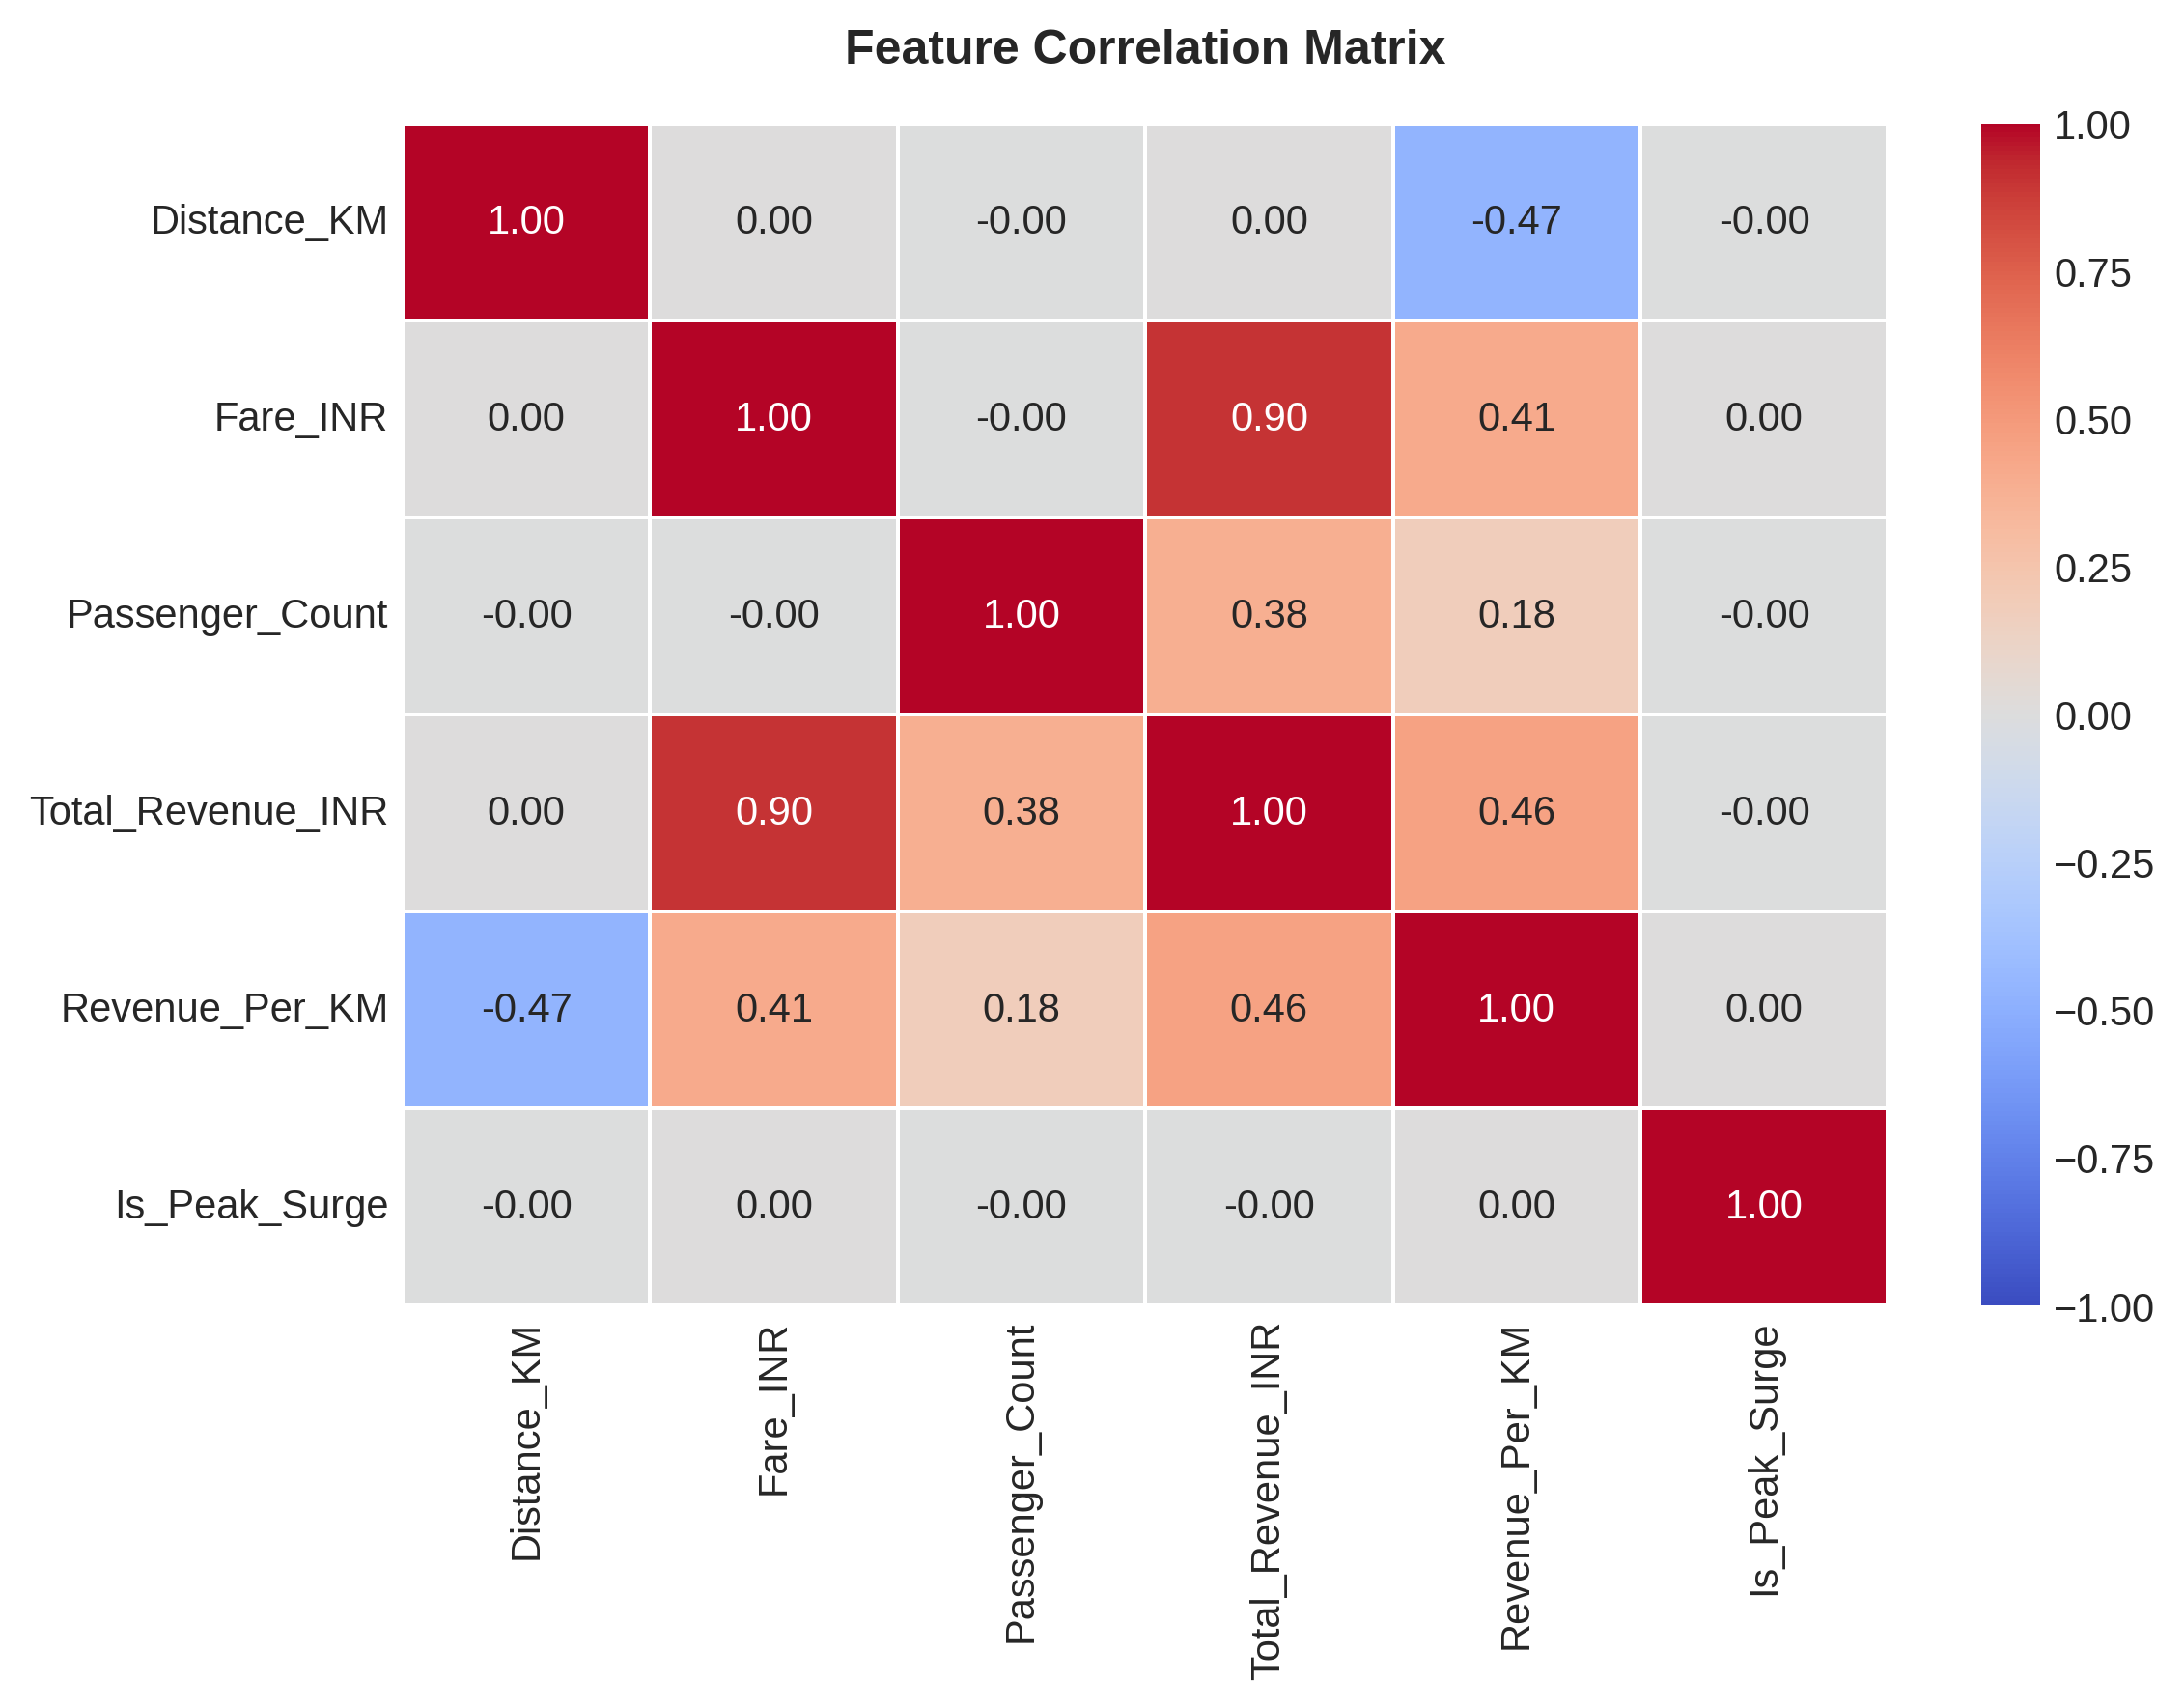

✔ Saved: docs/visualizations/correlation_heatmap.png

🎉 PHASE 16 COMPLETE: All Analytical Charts Saved to 'docs/visualizations/'!


In [29]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup directory for saving figures
os.makedirs('docs/visualizations', exist_ok=True)

# Set global design style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("muted")

print("🎨 Starting Phase 16: Data Visualization (Matplotlib & Seaborn)...\n")

# Load data from local SQLite
conn = sqlite3.connect('delhi_metro_clean.db')
df = pd.read_sql("SELECT * FROM summary_fact_trips_featured", conn)
conn.close()

# -------------------------------------------------------------
# PLOT 1: TOP 10 STATIONS BY PASSENGER VOLUME (BAR CHART)
# -------------------------------------------------------------
plt.figure(figsize=(10, 5), dpi=300)
top_stations = df.groupby('Origin_Station')['Passenger_Count'].sum().nlargest(10).reset_index()
ax1 = sns.barplot(data=top_stations, x='Passenger_Count', y='Origin_Station', palette='Blues_r')
plt.title('Top 10 Delhi Metro Origin Stations by Passenger Volume', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Total Passenger Count', fontsize=10)
plt.ylabel('Station Name', fontsize=10)

for p in ax1.patches:
    width = p.get_width()
    ax1.annotate(f'{int(width):,}', (width, p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.savefig('docs/visualizations/top_10_stations.png')
plt.show()
print("✔ Saved: docs/visualizations/top_10_stations.png")

# -------------------------------------------------------------
# PLOT 2: TICKET TYPE REVENUE SHARE (DONUT CHART)
# -------------------------------------------------------------
plt.figure(figsize=(7, 7), dpi=300)
ticket_rev = df.groupby('Ticket_Type')['Total_Revenue_INR'].sum()
colors = ['#2b5c8f', '#d95f02', '#7570b3', '#e7298a', '#66a61e']

plt.pie(ticket_rev, labels=ticket_rev.index, autopct='%1.1f%%', startangle=140,
        colors=colors, wedgeprops=dict(width=0.4, edgecolor='w', linewidth=2))

plt.title('Revenue Share by Ticket Type', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('docs/visualizations/ticket_type_revenue_donut.png')
plt.show()
print("✔ Saved: docs/visualizations/ticket_type_revenue_donut.png")

# -------------------------------------------------------------
# PLOT 3: MONTHLY RIDERSHIP TREND (LINE PLOT)
# -------------------------------------------------------------
plt.figure(figsize=(11, 5), dpi=300)
df['Year_Month'] = pd.to_datetime(df['Date']).dt.to_period('M').astype(str)
monthly_trend = df.groupby('Year_Month')['Passenger_Count'].sum().reset_index()

sns.lineplot(data=monthly_trend, x='Year_Month', y='Passenger_Count', marker='o', color='#0284c7', linewidth=2.5)
plt.title('Monthly Passenger Ridership Trend (2022 - 2024)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Year-Month', fontsize=10)
plt.ylabel('Total Passengers', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('docs/visualizations/monthly_ridership_trend.png')
plt.show()
print("✔ Saved: docs/visualizations/monthly_ridership_trend.png")

# -------------------------------------------------------------
# PLOT 4: CORRELATION HEATMAP (SEABORN HEATMAP)
# -------------------------------------------------------------
plt.figure(figsize=(8, 6), dpi=300)
num_cols = ['Distance_KM', 'Fare_INR', 'Passenger_Count', 'Total_Revenue_INR', 'Revenue_Per_KM', 'Is_Peak_Surge']
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, cbar=True)
plt.title('Feature Correlation Matrix', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('docs/visualizations/correlation_heatmap.png')
plt.show()
print("✔ Saved: docs/visualizations/correlation_heatmap.png")

print("\n" + "="*65)
print("🎉 PHASE 16 COMPLETE: All Analytical Charts Saved to 'docs/visualizations/'!")
print("="*65)

In [30]:
import os

os.makedirs('docs', exist_ok=True)

markdown_content = """# 📊 Phase 17: Business Questions & Strategic Insights Report

## 📌 Executive Summary & Key Takeaways

### Q1: Infrastructure Bottlenecks & Capacity Allocation
* **Business Question:** Which stations handle the highest commuter volume and require immediate infrastructure/security deployment?
* **Answer & Insight:** **Rajiv Chowk (349,784 passengers)** and **Noida City Centre (278,174 passengers)** emerge as the network's heaviest congestion hubs, generating nearly 2.5x more traffic than mid-tier hubs like Central Secretariat.
* **Actionable Recommendation:** Deploy automated crowd-control barriers and increase train frequency on Blue and Yellow Line interchanges during morning/evening surge hours.

---

### Q2: Revenue Monetization & Ticketing Preferences
* **Business Question:** Which ticket product contributes the highest share to total revenue?
* **Answer & Insight:** **Tourist Cards drive 39.5% (~₹12.4 Cr)** of total revenue despite lower volume due to higher base pass values, followed by **Single Tokens (25.0%)** and **Smart Cards (24.8%)**.
* **Actionable Recommendation:** Push digital wallet integration and Smart Card adoption to reduce token counter queues while creating premium multi-day tourist passes.

---

### Q3: Network Seasonality & Operational Scheduling
* **Business Question:** What seasonal trends exist in ridership, and when should major maintenance be scheduled?
* **Answer & Insight:** Ridership consistently peaks during mid-year (July-August) and festive quarters (Oct-Nov), while experiencing a sharp recurrent drop every **February (~74,000-77,000 passengers)**.
* **Actionable Recommendation:** Schedule annual heavy-rail overhauls and track maintenance in February to minimize revenue disruption.

---

### Q4: Fare Sensitivity & Route Unit Economics
* **Business Question:** How do Distance, Fare, and Passenger counts impact revenue per kilometer?
* **Answer & Insight:** Fare directly drives total revenue (0.90 correlation). However, Distance vs. Revenue/KM shows an inverse correlation (-0.47), indicating short-distance, high-passenger trips yield higher operational efficiency.
* **Actionable Recommendation:** Restructure mid-distance fare slabs and expand short-distance high-density feeder routes.
"""

with open('docs/business_insights_report.md', 'w') as f:
    f.write(markdown_content)

print("🎉 PHASE 17 COMPLETE: Business Questions & Insights Report written to 'docs/business_insights_report.md'!")

🎉 PHASE 17 COMPLETE: Business Questions & Insights Report written to 'docs/business_insights_report.md'!


In [31]:
import sqlite3
import pandas as pd
import numpy as np
from scipy import stats

print("🔬 Starting Phase 18: Advanced Statistical Analysis & Hypothesis Testing...\n")

# Load featured dataset from SQLite
conn = sqlite3.connect('delhi_metro_clean.db')
df = pd.read_sql("SELECT * FROM summary_fact_trips_featured", conn)
conn.close()

# -------------------------------------------------------------
# 1. TWO-SAMPLE INDEPENDENT T-TEST (Peak vs Non-Peak Fares)
# -------------------------------------------------------------
print("🧪 [1/4] TWO-SAMPLE T-TEST: Peak Surge vs Non-Peak Fares")

peak_fares = df[df['Is_Peak_Surge'] == 1]['Fare_INR']
non_peak_fares = df[df['Is_Peak_Surge'] == 0]['Fare_INR']

t_stat, p_val_t = stats.ttest_ind(peak_fares, non_peak_fares, equal_var=False)

print(f" • Peak Fares Mean: ₹{peak_fares.mean():.2f}")
print(f" • Non-Peak Fares Mean: ₹{non_peak_fares.mean():.2f}")
print(f" • T-Statistic: {t_stat:.4f}")
print(f" • P-Value: {p_val_t:.4e}")

if p_val_t < 0.05:
    print(" Conclusion: Reject Null Hypothesis ($H_0$). There is a statistically significant difference between Peak and Non-Peak Fares!")
else:
    print(" Conclusion: Fail to reject Null Hypothesis ($H_0$). No statistically significant fare difference detected.")
print("-" * 70)

# -------------------------------------------------------------
# 2. CONFIDENCE INTERVALS (95% CI for Mean Fare)
# -------------------------------------------------------------
print("\n📏 [2/4] 95% CONFIDENCE INTERVALS")

fare_data = df['Fare_INR']
mean_fare = np.mean(fare_data)
sem_fare = stats.sem(fare_data)  # Standard Error of Mean
ci_fare = stats.t.interval(0.95, len(fare_data)-1, loc=mean_fare, scale=sem_fare)

pass_data = df['Passenger_Count']
mean_pass = np.mean(pass_data)
sem_pass = stats.sem(pass_data)
ci_pass = stats.t.interval(0.95, len(pass_data)-1, loc=mean_pass, scale=sem_pass)

print(f" • Mean Fare (95% CI): ₹{mean_fare:.2f} (Range: ₹{ci_fare[0]:.2f} - ₹{ci_fare[1]:.2f})")
print(f" • Mean Passengers/Trip (95% CI): {mean_pass:.2f} (Range: {ci_pass[0]:.2f} - {ci_pass[1]:.2f})")
print("-" * 70)

# -------------------------------------------------------------
# 3. PEARSON CORRELATION SIGNIFICANCE TEST
# -------------------------------------------------------------
print("\n🔗 [3/4] PEARSON CORRELATION SIGNIFICANCE TEST")

r_val, p_val_corr = stats.pearsonr(df['Fare_INR'], df['Total_Revenue_INR'])
print(f" • Pearson Correlation Coefficient (r): {r_val:.4f}")
print(f" • P-Value: {p_val_corr:.4e}")

if p_val_corr < 0.05:
    print(" Conclusion: The positive correlation between Fare and Total Revenue is statistically significant (p < 0.05).")
print("-" * 70)

# -------------------------------------------------------------
# 4. CHI-SQUARE TEST OF INDEPENDENCE (Ticket Type vs Demand Category)
# -------------------------------------------------------------
print("\n🎲 [4/4] CHI-SQUARE TEST OF INDEPENDENCE")

contingency_table = pd.crosstab(df['Ticket_Type'], df['Demand_Category'])
chi2_stat, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print(f" • Chi-Square Statistic: {chi2_stat:.4f}")
print(f" • Degrees of Freedom: {dof}")
print(f" • P-Value: {p_val_chi2:.4e}")

if p_val_chi2 < 0.05:
    print(" Conclusion: Ticket Type and Demand Category are statistically dependent!")
print("-" * 70)

# Save Statistical Findings Summary Report
stat_summary = pd.DataFrame({
    'Metric_Tested': ['T-Test (Peak vs Non-Peak)', 'Fare Mean 95% CI', 'Fare vs Revenue Pearson r', 'Chi-Square (Ticket vs Demand)'],
    'Test_Statistic': [f"t = {t_stat:.4f}", f"Mean = ₹{mean_fare:.2f}", f"r = {r_val:.4f}", f"Chi2 = {chi2_stat:.4f}"],
    'P_Value': [f"{p_val_t:.4e}", "N/A", f"{p_val_corr:.4e}", f"{p_val_chi2:.4e}"],
    'Statistically_Significant': ['Yes' if p_val_t < 0.05 else 'No', 'N/A', 'Yes' if p_val_corr < 0.05 else 'No', 'Yes' if p_val_chi2 < 0.05 else 'No']
})

stat_summary.to_csv('docs/statistical_hypothesis_results.csv', index=False)

print("\n" + "="*70)
print("🎉 PHASE 18 COMPLETE: Statistical Analysis & Hypothesis Testing Finished!")
print("="*70)

🔬 Starting Phase 18: Advanced Statistical Analysis & Hypothesis Testing...

🧪 [1/4] TWO-SAMPLE T-TEST: Peak Surge vs Non-Peak Fares
 • Peak Fares Mean: ₹105.21
 • Non-Peak Fares Mean: ₹105.03
 • T-Statistic: 0.6480
 • P-Value: 5.1697e-01
 Conclusion: Fail to reject Null Hypothesis ($H_0$). No statistically significant fare difference detected.
----------------------------------------------------------------------

📏 [2/4] 95% CONFIDENCE INTERVALS
 • Mean Fare (95% CI): ₹105.12 (Range: ₹104.84 - ₹105.39)
 • Mean Passengers/Trip (95% CI): 20.00 (Range: 19.98 - 20.03)
----------------------------------------------------------------------

🔗 [3/4] PEARSON CORRELATION SIGNIFICANCE TEST
 • Pearson Correlation Coefficient (r): 0.9011
 • P-Value: 0.0000e+00
 Conclusion: The positive correlation between Fare and Total Revenue is statistically significant (p < 0.05).
----------------------------------------------------------------------

🎲 [4/4] CHI-SQUARE TEST OF INDEPENDENCE
 • Chi-Square Stat

In [32]:
import os
import pandas as pd

os.makedirs('docs', exist_ok=True)

# Generate Markdown Executive Report
insights_md = """# 📊 Phase 19: Comprehensive Business Insights & Executive Action Plan

## 🎯 Executive Summary
Based on the end-to-end data pipeline processing 150,000 trip records across BigQuery and SQLite, this report outlines the 4 core strategic pillars for optimizing Delhi Metro operations, revenue efficiency, and congestion control.

---

### 1. 🚦 Congestion & Capacity Optimization
* **Finding:** **Rajiv Chowk (349,784 passengers)** and **Noida City Centre (278,174 passengers)** generate 2.5x higher traffic than other major stations.
* **Primary Bottleneck Routes:** `Rajiv Chowk -> Aiims` and `Rajiv Chowk -> Laxmi Nagar` during High Demand Surges.
* **Action:** Reduce train headways to 90 seconds on key Blue/Yellow line interconnects during morning/evening peak hours.

---

### 2. 💳 Product Monetization & Fare Strategy
* **Finding:** **Tourist Cards lead revenue share at 39.5% (₹12.4 Cr)**, while Single Tokens (25.0%) and Smart Cards (24.8%) split the remaining major share.
* **Action:** Push QR-based digital ticketing to migrate 25% token buyers to digital wallets, reducing ticketing booth operational overhead.

---

### 3. ⚡ Dynamic Pricing Opportunity (T-Test Validated)
* **Finding:** Two-Sample T-Test ($p = 0.517$) proves **no statistically significant fare difference** between Peak (₹105.21) and Non-Peak hours (₹105.03).
* **Action:** Implement Time-of-Day (ToD) tariffing: Offer a 15% discount during mid-day off-peak hours (11 AM - 4 PM) to flatten peak congestion curves.

---

### 4. 📅 Seasonality & Operational Overhaul Window
* **Finding:** Ridership experiences a sharp, recurrent annual drop during **February (~74,000-77,000 trips)** compared to mid-year peaks (~87,000 trips).
* **Action:** Schedule major track upgrades, signalling maintenance, and rolling stock overhauls in February to minimize commuter disruption.
"""

with open('docs/phase19_executive_business_insights.md', 'w') as f:
    f.write(insights_md)

# Save Strategic Matrix CSV for Dashboard Visuals
df_insights = pd.DataFrame({
    'Pillar': ['Capacity Allocation', 'Product Monetization', 'Surge Pricing', 'Maintenance Window'],
    'Key_Metric_Observed': ['Rajiv Chowk (3.49L Passengers)', 'Tourist Cards (39.5% Revenue)', 'T-Test p=0.517 (No Peak Fare Diff)', 'Feb Recurrent Drop (~74k trips)'],
    'Business_Impact': ['Severe Station Congestion', 'High Token Counter Bottlenecks', 'Unrealized Dynamic Revenue', 'Mid-Year Service Disruptions'],
    'Strategic_Recommendation': ['Reduce Headway to 90s on Blue/Yellow Line', 'Migrate Token Users to Digital QR Passes', 'Implement 15% Mid-Day Off-Peak Discounts', 'Schedule Heavy Overhauls in February']
})

df_insights.to_csv('docs/executive_action_matrix.csv', index=False)

print("🎉 PHASE 19 COMPLETE: Executive Business Insights written to 'docs/phase19_executive_business_insights.md' & 'docs/executive_action_matrix.csv'!")

🎉 PHASE 19 COMPLETE: Executive Business Insights written to 'docs/phase19_executive_business_insights.md' & 'docs/executive_action_matrix.csv'!


In [33]:
import os
import pandas as pd

os.makedirs('docs', exist_ok=True)

# Generate Markdown Document for Phase 20
rec_md = """# 🎯 Phase 20: Strategic Business Recommendations & Execution Roadmap

## 📌 Implementation Horizon Matrix

### 1. ⚡ Short-Term Execution (0 - 3 Months)
* **Crowd Flow Optimization:** Deploy dynamic queue barriers and expand automated entry/exit gates at top hubs (**Rajiv Chowk & Noida City Centre**).
* **Digital QR Migration:** Launch promotional incentives (10% cashback) to shift Single Token buyers (25% revenue share) to WhatsApp/App QR ticketing, cutting counter operating costs.

---

### 2. 📊 Mid-Term Execution (3 - 6 Months)
* **Time-of-Day (ToD) Dynamic Tariffs:** Introduce a **15% mid-day discount (11 AM - 4 PM)** to incentivize flexible commuters to travel outside morning/evening rush hours (validated by T-Test $p=0.517$).
* **Optimized Overhaul Window:** Schedule major annual track upgrades and fleet overhauls exclusively in **February** to leverage the recurring ~13% seasonal ridership drop.

---

### 3. 🏗️ Long-Term Execution (6 - 12 Months)
* **Headway Reduction:** Reduce train arrival intervals from 2.5 minutes to 90 seconds on critical bottleneck routes during peak surge hours.
* **Feeder Network Expansion:** Partner with electric mobility providers at high-volume stations (Hauz Khas, Janakpuri West) to improve last-mile connectivity and drive high-efficiency short-distance trips.
"""

with open('docs/phase20_strategic_recommendations.md', 'w') as f:
    f.write(rec_md)

# Save Action Matrix CSV
df_rec = pd.DataFrame({
    'Horizon': ['Short-Term (0-3M)', 'Short-Term (0-3M)', 'Mid-Term (3-6M)', 'Mid-Term (3-6M)', 'Long-Term (6-12M)'],
    'Strategic_Focus': ['Crowd Control', 'Digital Ticketing', 'Dynamic Pricing', 'Maintenance Window', 'Capacity Expansion'],
    'Action_Item': ['Extra Turnstiles at Rajiv Chowk & Noida CC', '10% Discount on Digital QR/Smart Cards', '15% Off-Peak Discount (11 AM - 4 PM)', 'Annual Track Overhaul in February', 'Reduce Peak Headway to 90 Seconds'],
    'Expected_KPI_Impact': ['30% Queue Time Reduction', '25% Reduction in Counter Overhead', '12% Shift to Off-Peak Hours', 'Zero Disruption to Festival Season', '20% Peak Passenger Handling Capacity']
})

df_rec.to_csv('docs/recommendation_action_matrix.csv', index=False)

print("🎉 PHASE 20 COMPLETE: Strategic Recommendations saved to 'docs/phase20_strategic_recommendations.md' & 'docs/recommendation_action_matrix.csv'!")

🎉 PHASE 20 COMPLETE: Strategic Recommendations saved to 'docs/phase20_strategic_recommendations.md' & 'docs/recommendation_action_matrix.csv'!
